# ESS 배터리 수명 예측 - DAY 1 EDA

## 초기 배터리 신호로 총수명을 예측하는 모델 전략

### DAY 1 분석 목적

처음 100사이클에서 확보할 수 있는 신호로 배터리 셀의 총수명을 예측하는 회귀 전략을 수립한다. 세 배치의 EDA를 통해 핵심 신호, 배치 차이, 라벨 신뢰성과 모델 복잡도의 한계를 확인했다. 모델 학습·성능 평가는 이번 보고서의 범위가 아니다.

| 정의 | 본 프로젝트의 선택 |
| --- | --- |
| 분석 단위 | 배터리 셀 1개 = 모델 표본 1개. 116,722개 사이클 행을 독립 표본으로 취급하지 않는다. |
| X: 예측 시점의 입력 | 초기 100사이클까지의 방전곡선 변화, 용량 추세, 충전 조건, 온도·저항 |
| Y: Target | 원본 cycle_life: SOH 80%에 해당하는 총수명(사이클). 100사이클 시점 RUL과 구분. |
| 핵심 선택 | ΔQ log 분산으로 작은 기본 모델을 시작하고, 용량 기울기·충전시간·C-rate·온도를 단계적으로 추가한다. |
| 검증 원칙 | Batch 1 내부 CV·Hold-out으로 선택. Batch 2 필수 외부 평가, Batch 3 추가 평가. |

### 한눈에 보는 핵심 발견

전체 139개 셀 중 수명 라벨은 129개다. ΔQ log 분산과 수명의 상관은 Batch 1/2/3에서 -0.871/-0.709/-0.797로 방향이 일관된다. 충전시간과 초기 용량 기울기는 배치별 방향이 달라 조건 의존성이 크다. 따라서 모든 후보를 한 번에 넣는 전략을 피한다.

### 참고 이미지의 적용 방식

이미지의 매출·날씨·Tweedie 예시를 그대로 가져오지 않고, 탐색 목적 → 실제 관찰 → 처리 이유 → 처리 전후 확인 → 피처 및 후보 모델 선택의 논리 구조를 배터리 데이터에 적용했다. 캠퍼스·반·팀원 이름은 제출 전에 입력한다.


In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
if ROOT.name == "notebooks": ROOT = ROOT.parent
assert (ROOT / "src/eda.py").exists(), "ess_day1 또는 notebooks 폴더에서 실행하세요"
sys.path.insert(0, str(ROOT / "src"))
import eda
DATA_DIR = ROOT / "data/raw"
PROCESSED = ROOT / "data/processed"
print("원본 데이터:", DATA_DIR)

원본 데이터: /Users/dogyun/Downloads/ess_day1/data/raw


## 0. 로딩과 데이터 품질

원본 HDF5에서 summary와 초기 곡선만 읽습니다. 반복 실행에서는 이미 계산한 CSV/NPZ를 사용합니다. 원본을 바꾸면 `REBUILD=True`로 다시 생성하세요. 전압별 곡선과 summary의 실제 사이클 번호를 대응시킵니다.

In [2]:
REBUILD = False
if REBUILD or not (PROCESSED / "cell_features.csv").exists():
    cells, summary, curves = eda.extract(DATA_DIR, PROCESSED)
else:
    cells = pd.read_csv(PROCESSED / "cell_features.csv")
    summary = pd.read_csv(PROCESSED / "cycle_summary.csv")
    z = np.load(PROCESSED / "delta_curves.npz")
    curves = {k:z[k] for k in z.files}
eda.plots(cells, summary, curves, ROOT / "results")
eda.tables(cells, ROOT / "results")
import detailed_day1
_ = detailed_day1.analyze(ROOT)
stats = pd.read_csv(ROOT / "results/batch_statistics.csv")
corr = pd.read_csv(ROOT / "results/feature_correlations.csv")
display(stats)
display(cells.groupby("batch")[[c for c in cells if c.startswith("invalid_")]].sum())

,batch,n,n_labeled,label_missing,min,median,mean,max,short_lt500,long_gt1000,label0_lt550,label1_ge550,eol_not_observed,delta_usable,knee_candidates,policy_count
0,Batch 1,46,46,0,534.0,858.5,844.717391,1227.0,0,10,1,45,10,46,45,23
1,Batch 2,47,39,8,392.0,472.0,565.743590,1186.0,28,3,30,9,4,47,44,20
2,Batch 3,46,44,2,541.0,1005.5,1059.659091,1935.0,0,23,1,43,2,46,46,8


,invalid_QD,invalid_QC,invalid_IR,invalid_Tavg,invalid_Tmax,invalid_Tmin,invalid_chargetime
batch,,,,,,,
Batch 1,48,72,65,46,46,46,46
Batch 2,11,11,4904,8,101,125,0
Batch 3,0,0,0,0,0,0,0


## 입력 데이터·수집 구조·라벨 품질

| 배치 | 전체 / 라벨 | 결측 라벨 | 완료 불확실 | 파일 날짜 |
| --- | --- | --- | --- | --- |
| Batch 1 | 46 / 46 | 0 | 10 | 2017-05-12 |
| Batch 2 | 47 / 39 | 8 | 4 | 2018-02-20 |
| Batch 3 | 46 / 44 | 2 | 2 | 2018-04-12 |

### 수집·정리

Kaggle의 실습 지정 MAT 파일을 HDF5로 읽었다. 셀 스칼라(cycle_life·policy), summary(사이클별 용량·저항·온도·충전시간), cycles(사이클 내부 곡선)를 연결했다. 배치+원본 인덱스로 cell_id를 만들고 실제 사이클 번호와 곡선 참조를 대응시켰다. 원본 summary는 보존했다.

### 처리 전후

피처 계산에서 용량 ≤0 또는 >1.32 Ah, IR ≤0, 온도 ≤0 또는 >100°C, 충전시간 ≤0을 결측 처리했다. 셀 139개는 탐색용으로 유지하고 라벨 통계에서는 결측 10개만 제외했다. 완료 불확실 16개와 결측 10개는 겹치는 목록이므로 합산하지 않는다.

### 배치별 종료 방식의 차이

Batch 1의 46개와 Batch 3의 유효 라벨 44개는 cycle_life=마지막 기록 사이클+1이다. Batch 2의 유효 라벨 39개는 최초 QD<0.88 Ah 사이클과 cycle_life가 일치하고, 이후 측정도 남아 있다. 따라서 마지막 기록 사이클을 모든 배치의 타깃으로 쓰면 잘못된다.

### 완료 불확실 기준과 누락

종료 시 유효 QD>0.885 Ah 또는 미제공을 완료 불확실로 표시했다. 단일 기준은 EOL의 확정 판정이 아니다. Batch 1의 일부 종료 용량은 0.91~1.04 Ah여서 라벨이 실제 EOL보다 관측 종료를 나타낼 가능성을 검토해야 한다. 원본 3개 모두 초기 10·100사이클의 유효 ΔQ 곡선은 확보됐다.

### 데이터 출처의 차이

실습 Batch 2는 2018-02-20이며 연구진 공개 로더의 2017-06-30과 다르다. 공개 코드의 병합·제외 인덱스를 그대로 적용하지 않았다. 상세 원본 대조와 결측/품질 목록은 results의 검증 파일로 제공한다.


In [3]:
display(cells.loc[cells.eol_not_observed | ~cells.delta_available | cells.cycle_life.isna(), ["cell_id","batch","cycle_life","last_cycle","qd_last_valid","eol_not_observed","delta_available"]])
display(pd.DataFrame(json.loads((PROCESSED / "data_manifest.json").read_text())))

,cell_id,batch,cycle_life,last_cycle,qd_last_valid,eol_not_observed,delta_available
0,b1c0,Batch 1,1190.0,1189.0,1.026210,True,True
1,b1c1,Batch 1,1179.0,1178.0,1.038225,True,True
2,b1c2,Batch 1,1177.0,1176.0,1.043279,True,True
3,b1c3,Batch 1,1226.0,1225.0,0.970921,True,True
4,b1c4,Batch 1,1227.0,1226.0,1.021960,True,True
8,b1c8,Batch 1,879.0,878.0,0.969025,True,True
10,b1c10,Batch 1,906.0,905.0,0.961019,True,True
12,b1c12,Batch 1,902.0,901.0,0.913119,True,True
13,b1c13,Batch 1,897.0,896.0,0.923136,True,True
22,b1c22,Batch 1,891.0,890.0,0.963279,True,True


,batch,file,bytes,raw_cells,download_url,sha256,retrieved_date
0,Batch 1,2017-05-12_batchdata_updated_struct_errorcorre...,3025320241,46,https://www.kaggle.com/api/v1/datasets/downloa...,9d928ab978f0e3c70b31cb833a749fedd35094d01af764...,2026-10-01
1,Batch 2,2018-02-20_batchdata_updated_struct_errorcorre...,2022599329,47,https://www.kaggle.com/api/v1/datasets/downloa...,3487db505ad08b6c805f41dd0560e73b54077c76aca04f...,2026-10-01
2,Batch 3,2018-04-12_batchdata_updated_struct_errorcorre...,3236690412,46,https://www.kaggle.com/api/v1/datasets/downloa...,62c30e413b63e6144720e016deed3661fac8468641794a...,2026-10-01


## 1. Cycle life 분포

장수명 >1,000 / 단수명 <500은 EDA 그룹이고, 분류 라벨 ≥550 기준과는 다릅니다. 이상치는 자동 제거하지 않고 종료 여부·측정 품질을 함께 확인합니다.

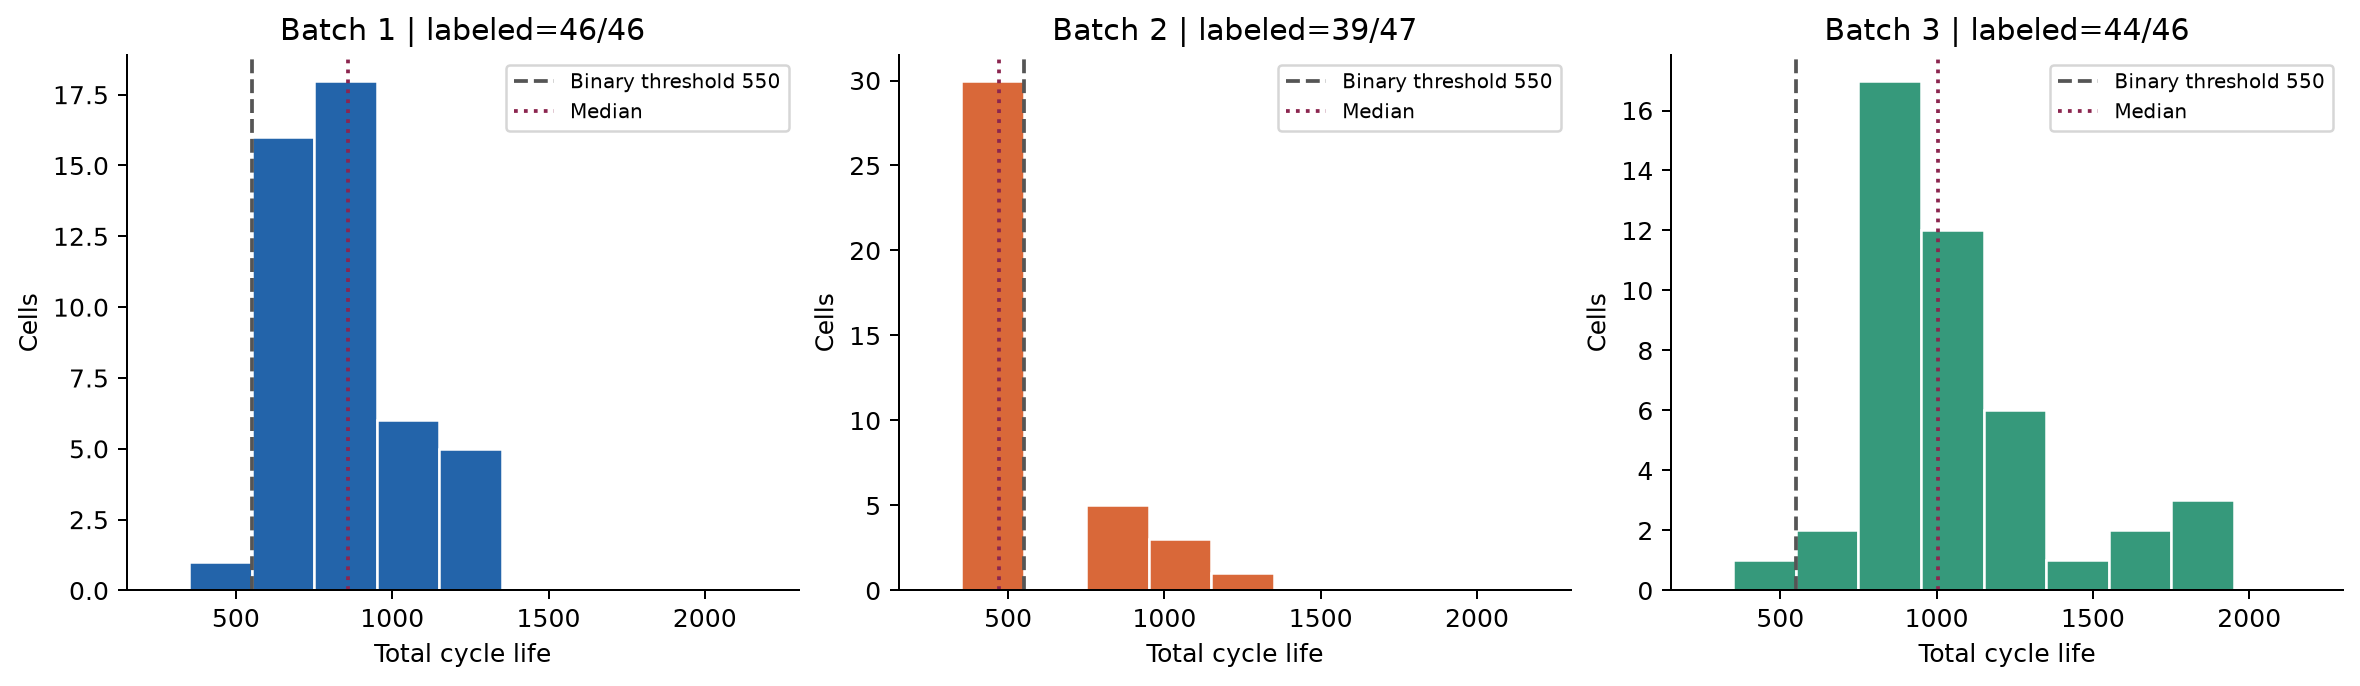

,batch,n,min,median,mean,max,short_lt500,long_gt1000,label0_lt550,label1_ge550
0,Batch 1,46,534.0,858.5,844.717391,1227.0,0,10,1,45
1,Batch 2,47,392.0,472.0,565.743590,1186.0,28,3,30,9
2,Batch 3,46,541.0,1005.5,1059.659091,1935.0,0,23,1,43


,cell_id,batch,cycle_life,charging_policy,eol_not_observed
65,b2c19,Batch 2,392.0,6C(60%)-3C,False
52,b2c6,Batch 2,393.0,3.6C(9%)-5C,False
61,b2c15,Batch 2,396.0,3.6C(9%)-5C,False
67,b2c21,Batch 2,408.0,6C(60%)-3C,False
76,b2c30,Batch 2,412.0,5.6C(26%)-4.5C,False
51,b2c5,Batch 2,416.0,3.6C(30%)-6C,False
48,b2c2,Batch 2,424.0,5.2C(50%)-4.25C,False
77,b2c31,Batch 2,425.0,5.6C(26%)-4.5C,False
60,b2c14,Batch 2,426.0,3.6C(30%)-6C,False
74,b2c28,Batch 2,437.0,4.8C(80%)-4.8C,False


In [4]:
display(Image(filename=str(ROOT / "results/01_life_distribution.png")))
display(stats[["batch","n","min","median","mean","max","short_lt500","long_gt1000","label0_lt550","label1_ge550"]])
display(cells.nsmallest(10,"cycle_life")[["cell_id","batch","cycle_life","charging_policy","eol_not_observed"]])

## Q1. Cycle Life 분포: 배치 차이는 무엇인가?

### 탐색 목적

학습 범위와 외부 평가 범위가 얼마나 다른지 확인하고, 짧은 수명이 일부 오류인지 일반적인 배치 특성인지 구분한다. 150~2,300사이클의 같은 축으로 비교한다.

| 배치 | 중앙값 / 평균 | 범위 | <500 | >1000 |
| --- | --- | --- | --- | --- |
| Batch 1 | 858.5 / 844.7 | 534~1227 | 0 (0.0%) | 10 (21.7%) |
| Batch 2 | 472.0 / 565.7 | 392~1186 | 28 (71.8%) | 3 (7.7%) |
| Batch 3 | 1005.5 / 1059.7 | 541~1935 | 0 (0.0%) | 23 (52.3%) |

### 관찰·배치 비교

Batch 1은 중앙값 858.5로 중간 수명에 집중한다. Batch 2는 중앙값 472.0이고 71.8%가 500 미만으로, 단수명이 지배적이다. Batch 3는 중앙값 1005.5이고 52.3%가 1000 초과다. 세 배치 모두 오른쪽 꼬리가 있으나 Batch 2·3에서 더 두드러진다.

### 시사점 → 전략

Batch 1의 유효 수명 범위는 534~1227이다. Batch 2의 <534 구간과 Batch 3의 >1227 구간은 학습 타깃 범위 밖이므로 해당 구간의 잔차와 MAPE를 별도로 점검한다. 이것이 입력 X의 외삽을 확정하는 것은 아니며, 실제 입력 피처의 지원 범위도 함께 확인해야 한다.

### 분모와 그룹 정의

비율의 분모는 수명 라벨이 있는 셀 46/39/44개다. EDA의 장·단수명 기준(>1000/<500)과 분류 과제의 기준(≥550/<550)은 다른 정의다. 500~1000은 중간 그룹이다.

## Q1. 짧은 셀은 왜 짧은가? 이상치와 구분

| 배치 | 배치 내 최단 셀 | 수명 | 충전 정책 | 종료 QD |
| --- | --- | --- | --- | --- |
| Batch 1 | b1c20 | 534 | 5.4C(80%)-5.4C | 0.881 Ah |
| Batch 2 | b2c19 | 392 | 6C(60%)-3C | 0.826 Ah |
| Batch 3 | b3c28 | 541 | 3.7C(31%)-5.9C-newstructure | 0.880 Ah |

### 통계적 이상치 확인

배치별 1.5×IQR 기준에서 낮은 수명 이상치는 모두 0개다. 짧은 셀을 자동으로 이상치라고 부르면 안 된다. 높은 수명 후보는 Batch 1 0개, Batch 2 9개, Batch 3 3개다. 분포의 꼬리라는 이유만으로 정상 장수명 셀을 삭제하지 않는다.

### 짧은 셀의 근거: b2c19

수명 392사이클, 정책 6C(60%)-3C다. 최초 QD<0.88 Ah 사이클도 392로 타깃과 일치한다. ΔQ log 분산은 -3.292로 Batch 2 장수명 그룹 중앙값 -4.271보다 크다. 실제 초기 곡선 변화가 큰 짧은 셀이며, 종료 기록 오류만으로 짧아진 사례라는 근거는 없다.

### 프로토콜 대조

같은 6C(60%)-3C 정책의 평균 수명은 400.0±11.3(n=2)이다. 다른 짧은 정책인 3.6C(9%)-5C도 394.5±2.1(n=2)로 짧다. 첫 단계 C-rate가 낮아도 뒤 단계가 높을 수 있어 “첫 단계가 빠르기 때문에 짧다”는 단일 설명은 부족하다.

### 완료 불확실 셀과의 차이

예를 들어 b1c0는 라벨 1190이지만 마지막 용량 1.026 Ah로 아직 0.88 Ah에 도달하지 않았다. 이런 라벨 신뢰성 문제와 실제 단수명을 분리해야 한다. 높은 수명 정책 평균에는 완료 불확실 셀이 포함될 수 있으므로 그대로 정책 우열을 결론내리지 않는다.

### 시사점 → 처리

짧은 정상 셀을 삭제하지 않고, 결측 라벨·종료 불확실·측정 오류를 각각 플래그로 관리한다. 짧은 수명의 확정 원인은 실험 통제나 추가 메타데이터 없이는 규명할 수 없다. ΔQ·후반 충전 단계·온도 차이는 검증할 가설이다.


## 2. 열화 곡선과 knee 후보

색상은 실제 총수명에 대응합니다. EOL 표시선은 공칭 1.1 Ah × 80% = 0.88 Ah입니다. 전체 수명 궤적은 탐색용이며 모델 입력은 초기 100사이클 이내로 제한합니다.

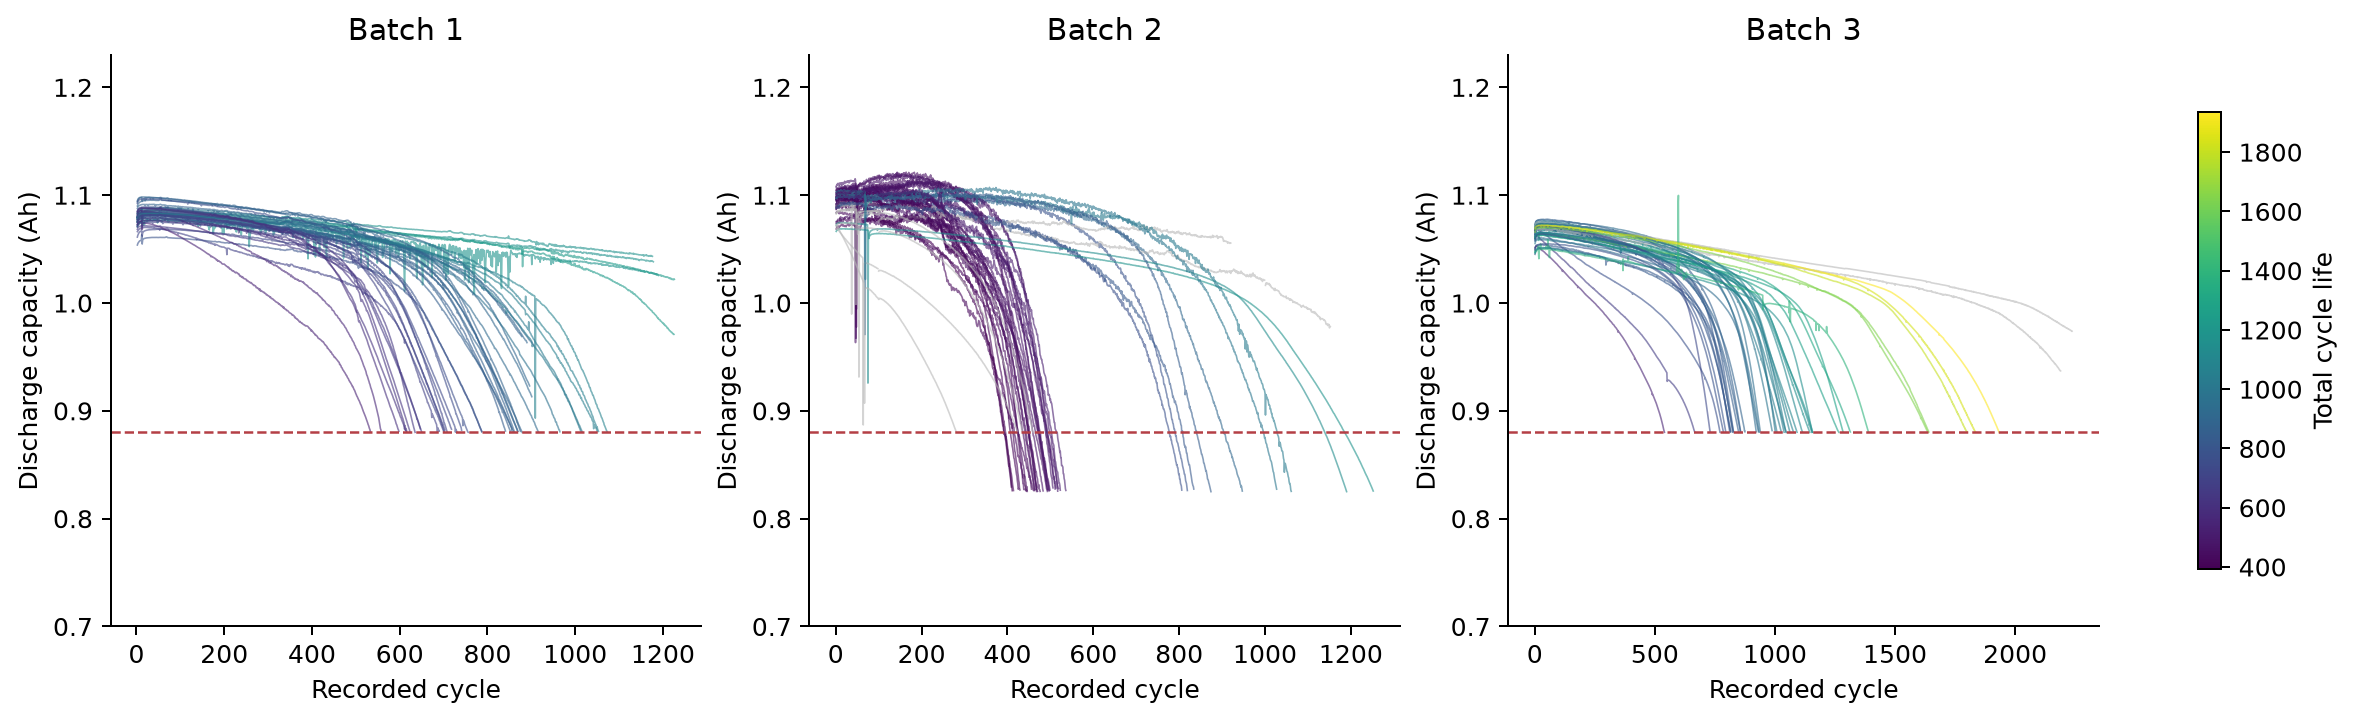

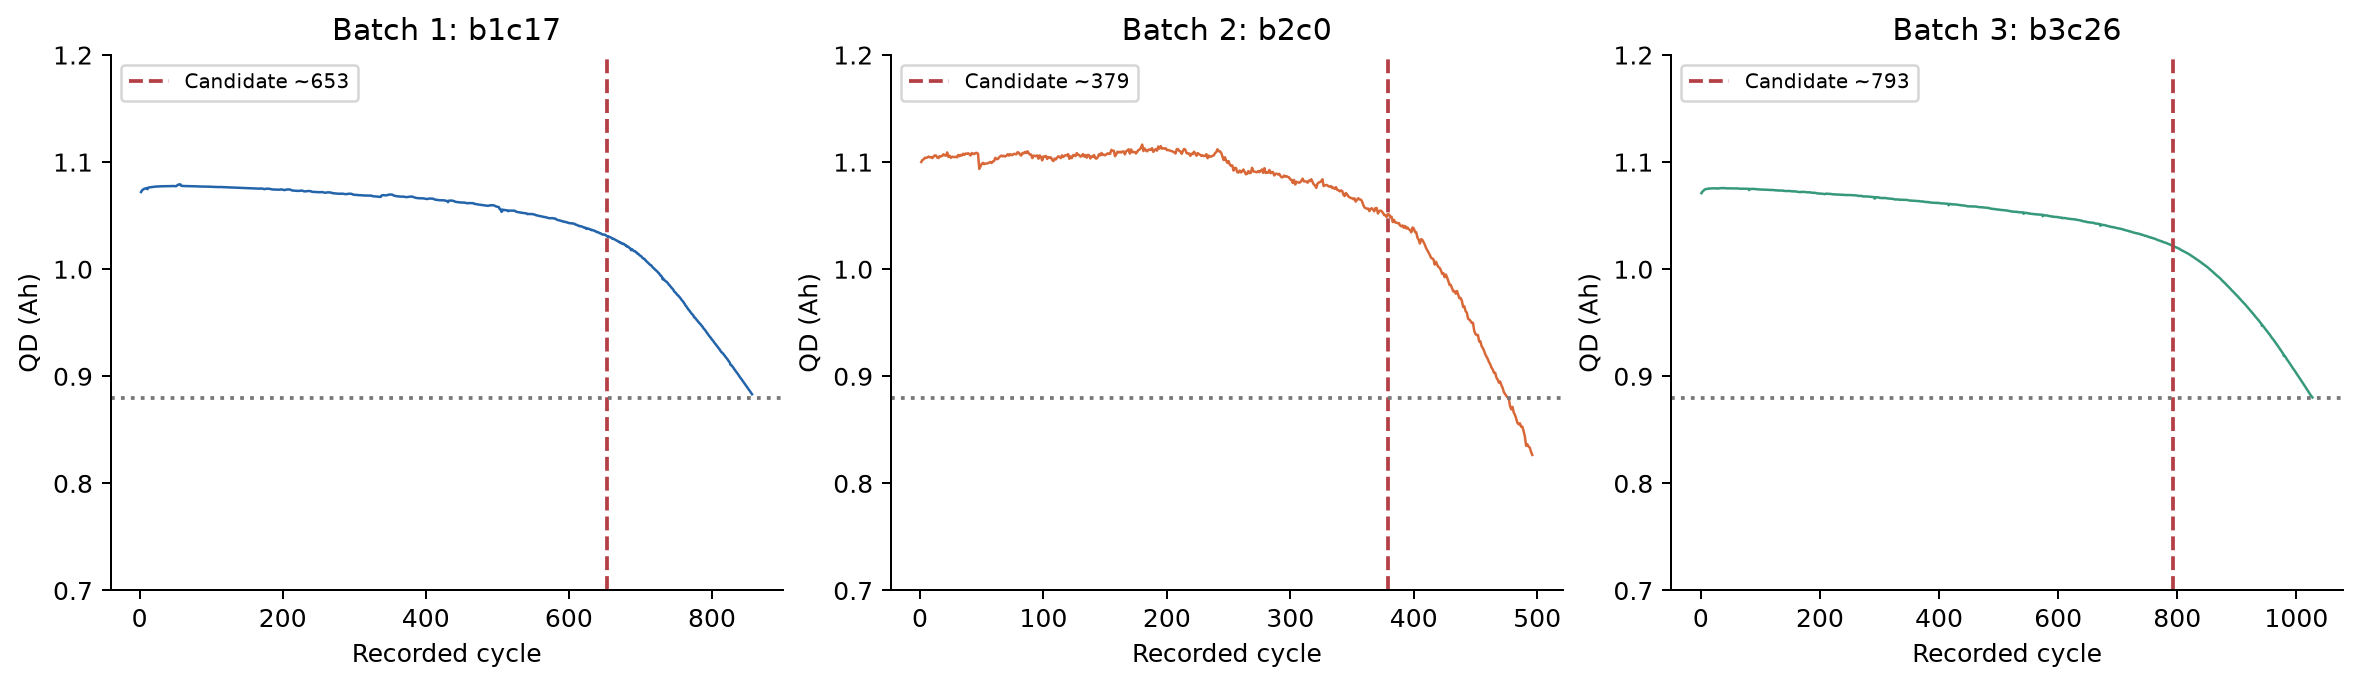

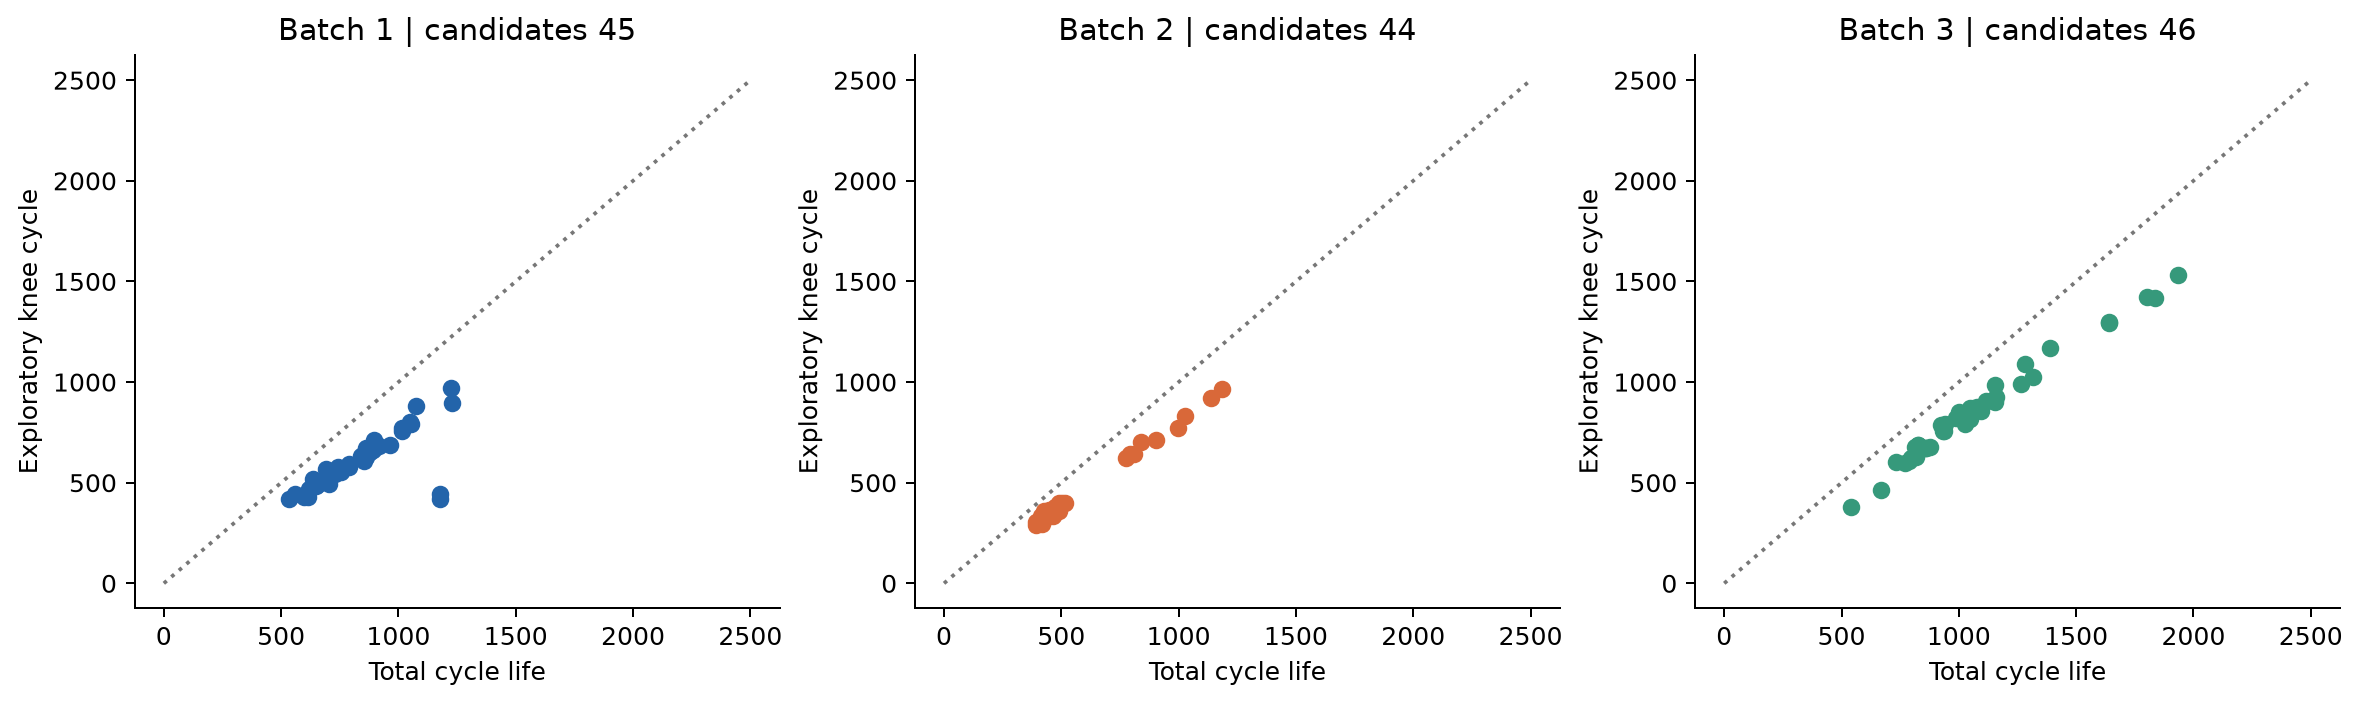

,count,median,min,max
batch,,,,
Batch 1,45,608.530,417.94,969.85
Batch 2,44,354.195,196.30,966.34
Batch 3,46,830.040,381.00,1902.95


In [5]:
display(Image(filename=str(ROOT / "results/02_degradation.png")))
display(Image(filename=str(ROOT / "results/09_knee_examples.png")))
display(Image(filename=str(ROOT / "results/07_knee_candidates.png")))
display(cells.groupby("batch").knee_cycle.agg(["count","median","min","max"]))

## Q2. 방전용량은 일정하게 감소하는가?

### 관찰·배치 비교

세 배치에서 완만한 초기 감소 뒤 더 급격해지는 말기 구간이 보인다. Batch 2는 상대적으로 짧은 기록과 빠른 종료가 많고, Batch 3는 긴 사이클 동안 완만하게 유지되는 셀이 많다. 색은 실제 수명이며 회색은 결측 라벨이다. 초기 용량 수준만으로 전체 수명을 구분하기 어렵다.

| 배치 | 초기 평균 QD의 셀 평균 | 초기 기울기 >0인 셀 | 초기 QD 기울기 vs 수명 ρ |
| --- | --- | --- | --- |
| Batch 1 | 1.082 Ah | 12 / 46 | +0.578 |
| Batch 2 | 1.091 Ah | 23 / 47 | -0.271 |
| Batch 3 | 1.066 Ah | 1 / 46 | +0.184 |

### 초기 기울기의 해석

초기 10~100사이클 용량이 증가하는 셀도 Batch 1/2/3에서 12/23/1개다. 초기 안정화나 측정 특성의 가능성이 있어 기울기가 항상 열화 속도를 뜻한다고 단정할 수 없다. 특히 수명 상관이 +0.578/-0.271/+0.184로 바뀌므로 ΔQ와 같은 범용 신호로 취급하지 않는다.

### 시사점 → 피처

초기 100사이클의 용량 기울기·평균·변동성은 후보로 유지하지만, ΔQ 단일 모델에 추가했을 때 Batch 1 검증 성능이 개선되는지 확인한다. 전체 궤적이나 말기 감소율을 입력으로 쓰면 100사이클 예측 시점을 어긴다.

### 그래프 해석의 한계

말기 QD 0.88 Ah 선은 공칭 1.1 Ah의 80%다. Batch 2는 라벨 이후 측정도 포함하고 Batch 1·3는 EOL 직전 종료가 흔하므로, 곡선 길이만으로 배치의 실제 열화 특성을 판단하지 않는다.

## Q2. Knee point: 가속 열화의 탐색적 후보

| 배치 | 후보 / 전체 | knee 사이클 중앙값 | knee / 수명 중앙값² |
| --- | --- | --- | --- |
| Batch 1 | 45 / 46 | 608.5 | 75.2% (n=45) |
| Batch 2 | 44 / 47 | 354.2 | 78.2% (n=39) |
| Batch 3 | 46 / 46 | 830.0 | 79.2% (n=44) |

### 방법

10사이클 이후 QD 0.80~1.32 Ah의 유효점에 11점 중앙값 평활화를 적용한다. 기록 구간의 15~85%에서 연속 두 직선의 전환점을 탐색한다. 단일 직선 대비 SSE 20% 이상 개선, 후반 기울기 음수, 후반 절댓값이 전반의 1.5배 초과일 때 후보로 표시한다.

### 발견과 한계

후보가 45/44/46개로 대부분의 셀에서 탐지된다. 이는 곡률에 민감한 탐색 규칙이며 모든 셀에 물리적 knee가 확정됐다는 뜻이 아니다. 위치는 평활화·탐색 범위·측정 종료에 의존한다. Batch 2의 라벨 이후 기록도 이 탐색에 포함한다.

### 시사점 → 모델 설계

대체로 기록 후반의 가속 열화가 초기 정보와 다르다는 점을 확인했다. knee 위치는 수명 전체가 있어야 계산되므로 입력에서 제외한다. 100사이클 이전의 국소 추세만 후보로 사용하고, 물리적 knee 검증은 별도 과제로 둔다.

### 통계 분모

² 셀별 knee/cycle_life를 계산한 뒤 중앙값을 낸 값이다. 결측 라벨은 비율에서 제외하며, 후보 사이클 중앙값은 라벨 없는 셀도 포함한 후보 전체 기준이다. 따라서 두 요약의 분모가 다르다.


## 3. ΔQ(V) — Q100(V) − Q10(V)

Qdlin의 두 사이클을 같은 보간 위치에서 뺍니다. raw Qd를 시간 위치에 따라 직접 빼지 않습니다. 유효점 900개 이상인 1,000포인트 곡선에서 log 분산·최솟값·평균을 계산합니다.

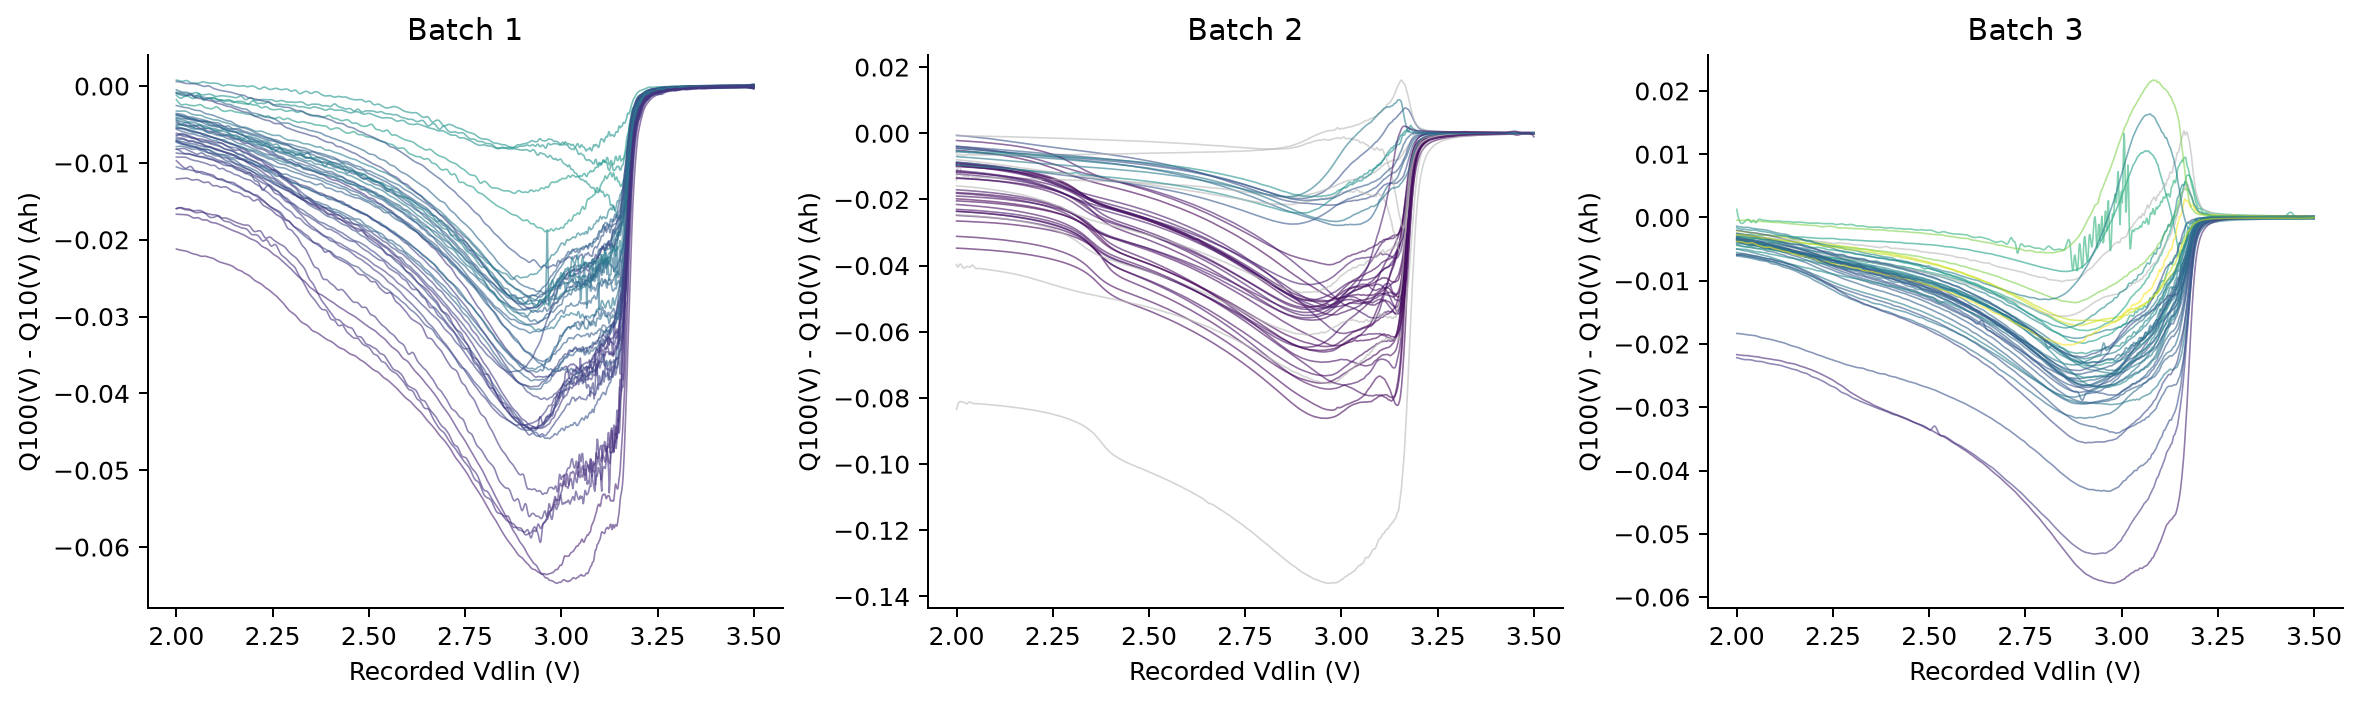

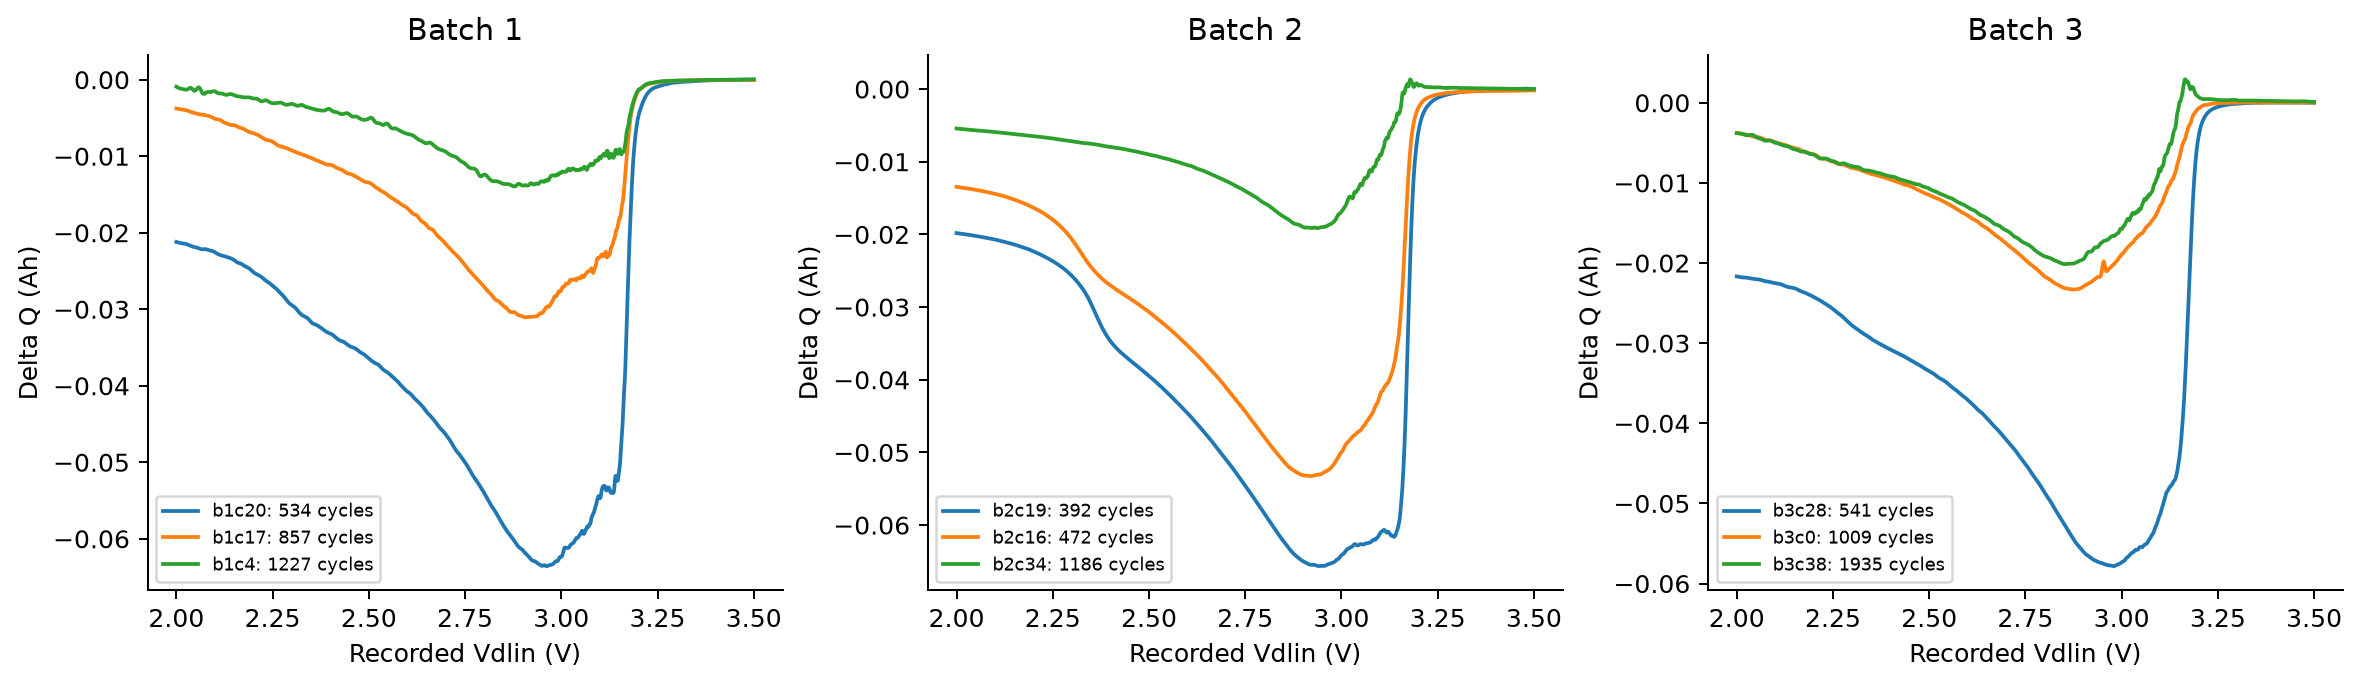

,cell_id,batch,cycle_life,log_var_delta_q,min_delta_q,mean_delta_q,delta_available
0,b1c0,Batch 1,1190.0,-5.014427,-0.008460,-0.002873,True
1,b1c1,Batch 1,1179.0,-5.013525,-0.011004,-0.004100,True
2,b1c2,Batch 1,1177.0,-4.736565,-0.017216,-0.004487,True
3,b1c3,Batch 1,1226.0,-4.442179,-0.018961,-0.007456,True
4,b1c4,Batch 1,1227.0,-4.647309,-0.013958,-0.005750,True
5,b1c5,Batch 1,1074.0,-4.178443,-0.025179,-0.011074,True
6,b1c6,Batch 1,636.0,-3.768443,-0.037886,-0.015965,True
7,b1c7,Batch 1,870.0,-3.813052,-0.038233,-0.016646,True
8,b1c8,Batch 1,879.0,-4.000760,-0.030808,-0.012819,True
9,b1c9,Batch 1,1054.0,-4.058949,-0.028724,-0.011511,True


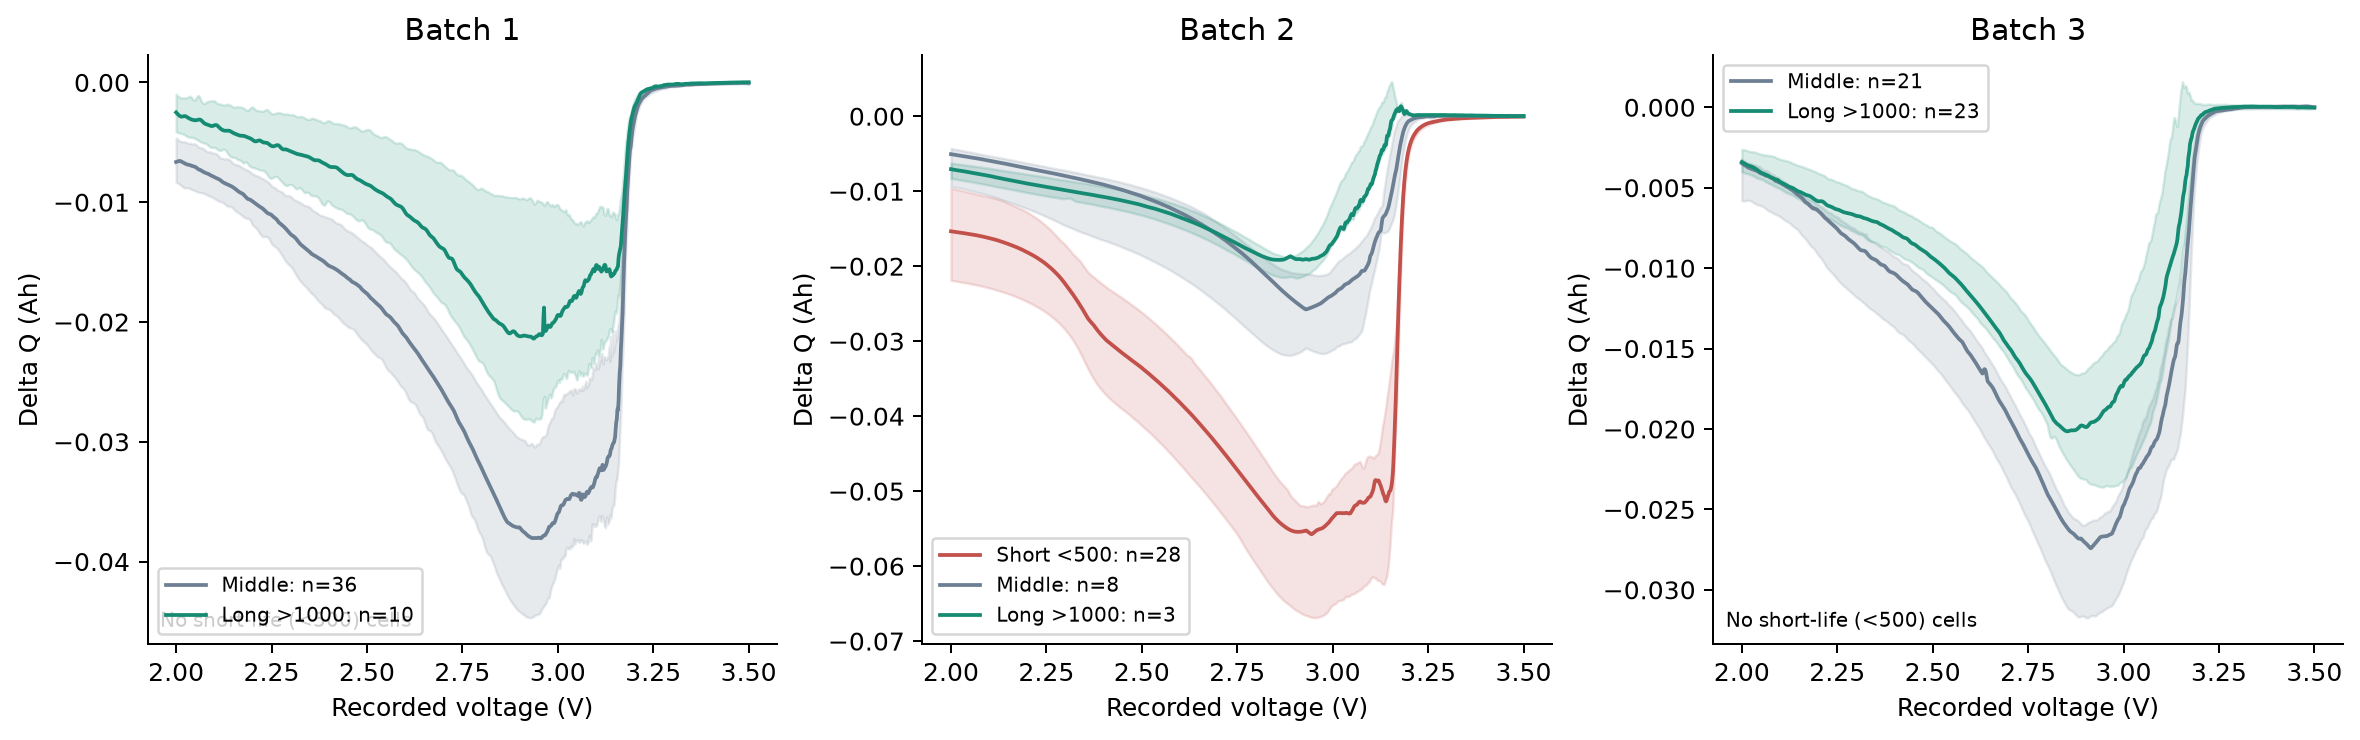

In [6]:
display(Image(filename=str(ROOT / "results/03_delta_q.png")))
display(Image(filename=str(ROOT / "results/08_delta_examples.png")))
display(cells[["cell_id","batch","cycle_life","log_var_delta_q","min_delta_q","mean_delta_q","delta_available"]].head(12))
display(Image(filename=str(ROOT / "results/11_delta_life_groups.png")))

## Q3. ΔQ(V): 장·단수명 그룹의 실제 차이

### 계산 정의

실제 사이클 번호 100과 10을 선택하고, 동일 Vdlin 축에서 ΔQ(V)=Q100(V)-Q10(V)를 계산했다. 시간축이 다른 원시 Qd를 직접 빼지 않는다. 전압은 가이드의 설명 범위 대신 실제 Vdlin 3.5→2.0 V를 사용했다.

### 그래프 읽기

선은 그룹별 중앙값, 음영은 25~75% 범위다. 그룹 내부 변동도 함께 보이므로 최단·최장 셀 한 쌍만 비교할 때보다 대표성이 높다. 다만 Batch 2 장수명은 n=3으로 요약 곡선의 안정성은 제한적이다. Batch 2의 단수명 그룹은 약 3 V 부근에서 더 깊은 음의 변화가 보이며 장수명 그룹은 변화가 작다.

### 존재하지 않는 그룹을 만들지 않기

Batch 1과 Batch 3에는 <500사이클 단수명 셀이 없다. 따라서 이 두 배치는 중간(500~1000)과 장수명(>1000)을 비교했다. 기존 최단/중앙/최장 예시 셀 그래프를 보조자료로 유지하되 최단 셀을 <500 그룹이라고 부르지 않는다.

### 시사점 → 피처

곡선의 변화 크기와 퍼짐을 log 분산·최솟값·평균으로 요약한다. 전체 1000개 전압 포인트를 한 번에 입력하면 46개 학습 셀보다 차원이 훨씬 커져 과적합 가능성이 높다. 작은 요약 피처부터 검증한다.

## Q3. 곡선에서 추출한 통계값과 피처 선택

| 배치 / 그룹 | n | log10 분산 중앙값 | ΔQ 최솟값 중앙값 | ΔQ 평균 중앙값 |
| --- | --- | --- | --- | --- |
| Batch 1 / 중간 | 36 | -3.786 | -0.0383 | -0.0172 |
| Batch 1 / 장수명 | 10 | -4.310 | -0.0221 | -0.0093 |
| Batch 2 / 단수명 | 28 | -3.446 | -0.0562 | -0.0287 |
| Batch 2 / 중간 | 8 | -4.153 | -0.0271 | -0.0112 |
| Batch 2 / 장수명 | 3 | -4.271 | -0.0192 | -0.0081 |
| Batch 3 / 중간 | 21 | -4.091 | -0.0276 | -0.0118 |
| Batch 3 / 장수명 | 23 | -4.316 | -0.0201 | -0.0087 |

### 발견

Batch 2의 단수명/장수명 log 분산 중앙값은 -3.446/-4.271이다. 최솟값은 -0.0562/-0.0192 Ah로 단수명에서 더 깊다. Batch 1과 Batch 3에서도 중간 대비 장수명 그룹의 log 분산과 용량 변화 절댓값이 작다.

### 피처 정의

log_var_delta_q=log10(var(ΔQ, ddof=1)), min_delta_q=min(ΔQ), mean_delta_q=mean(ΔQ)다. 로그는 작은 분산의 크기 차이를 비교하기 쉽도록 적용했으며 로그 자체가 예측 성능을 보장하지 않는다. 1000포인트 중 유효점 900개 이상 등 곡선 품질 조건을 확인했다.

### 선정과 중복 제어

세 배치에서 log 분산과 수명 관계가 강하고 방향이 일치하므로 핵심 피처로 우선 선택한다. 최솟값·평균은 대체 요약량 또는 정규화 모델의 후보로 비교한다. ΔQ 세 변수를 무조건 동시에 넣지 않는다.

### 추가 검증

Batch 1에서 완료 불확실 10개를 제외해도 log 분산 상관은 -0.871(n=46)→-0.826(n=36)으로 유지된다. 전압 구간별 피처를 추가할 경우 선택은 Batch 1 학습 fold 안에서만 수행하며 외부 타깃으로 최적화하지 않는다.


## 4. 충전 조건과 수명

C-rate 단계와 전환 SOC, 초기 실제 전류 및 충전시간을 비교합니다. 정책별 평균만 보지 않고 표준편차와 표본 수도 함께 확인합니다.

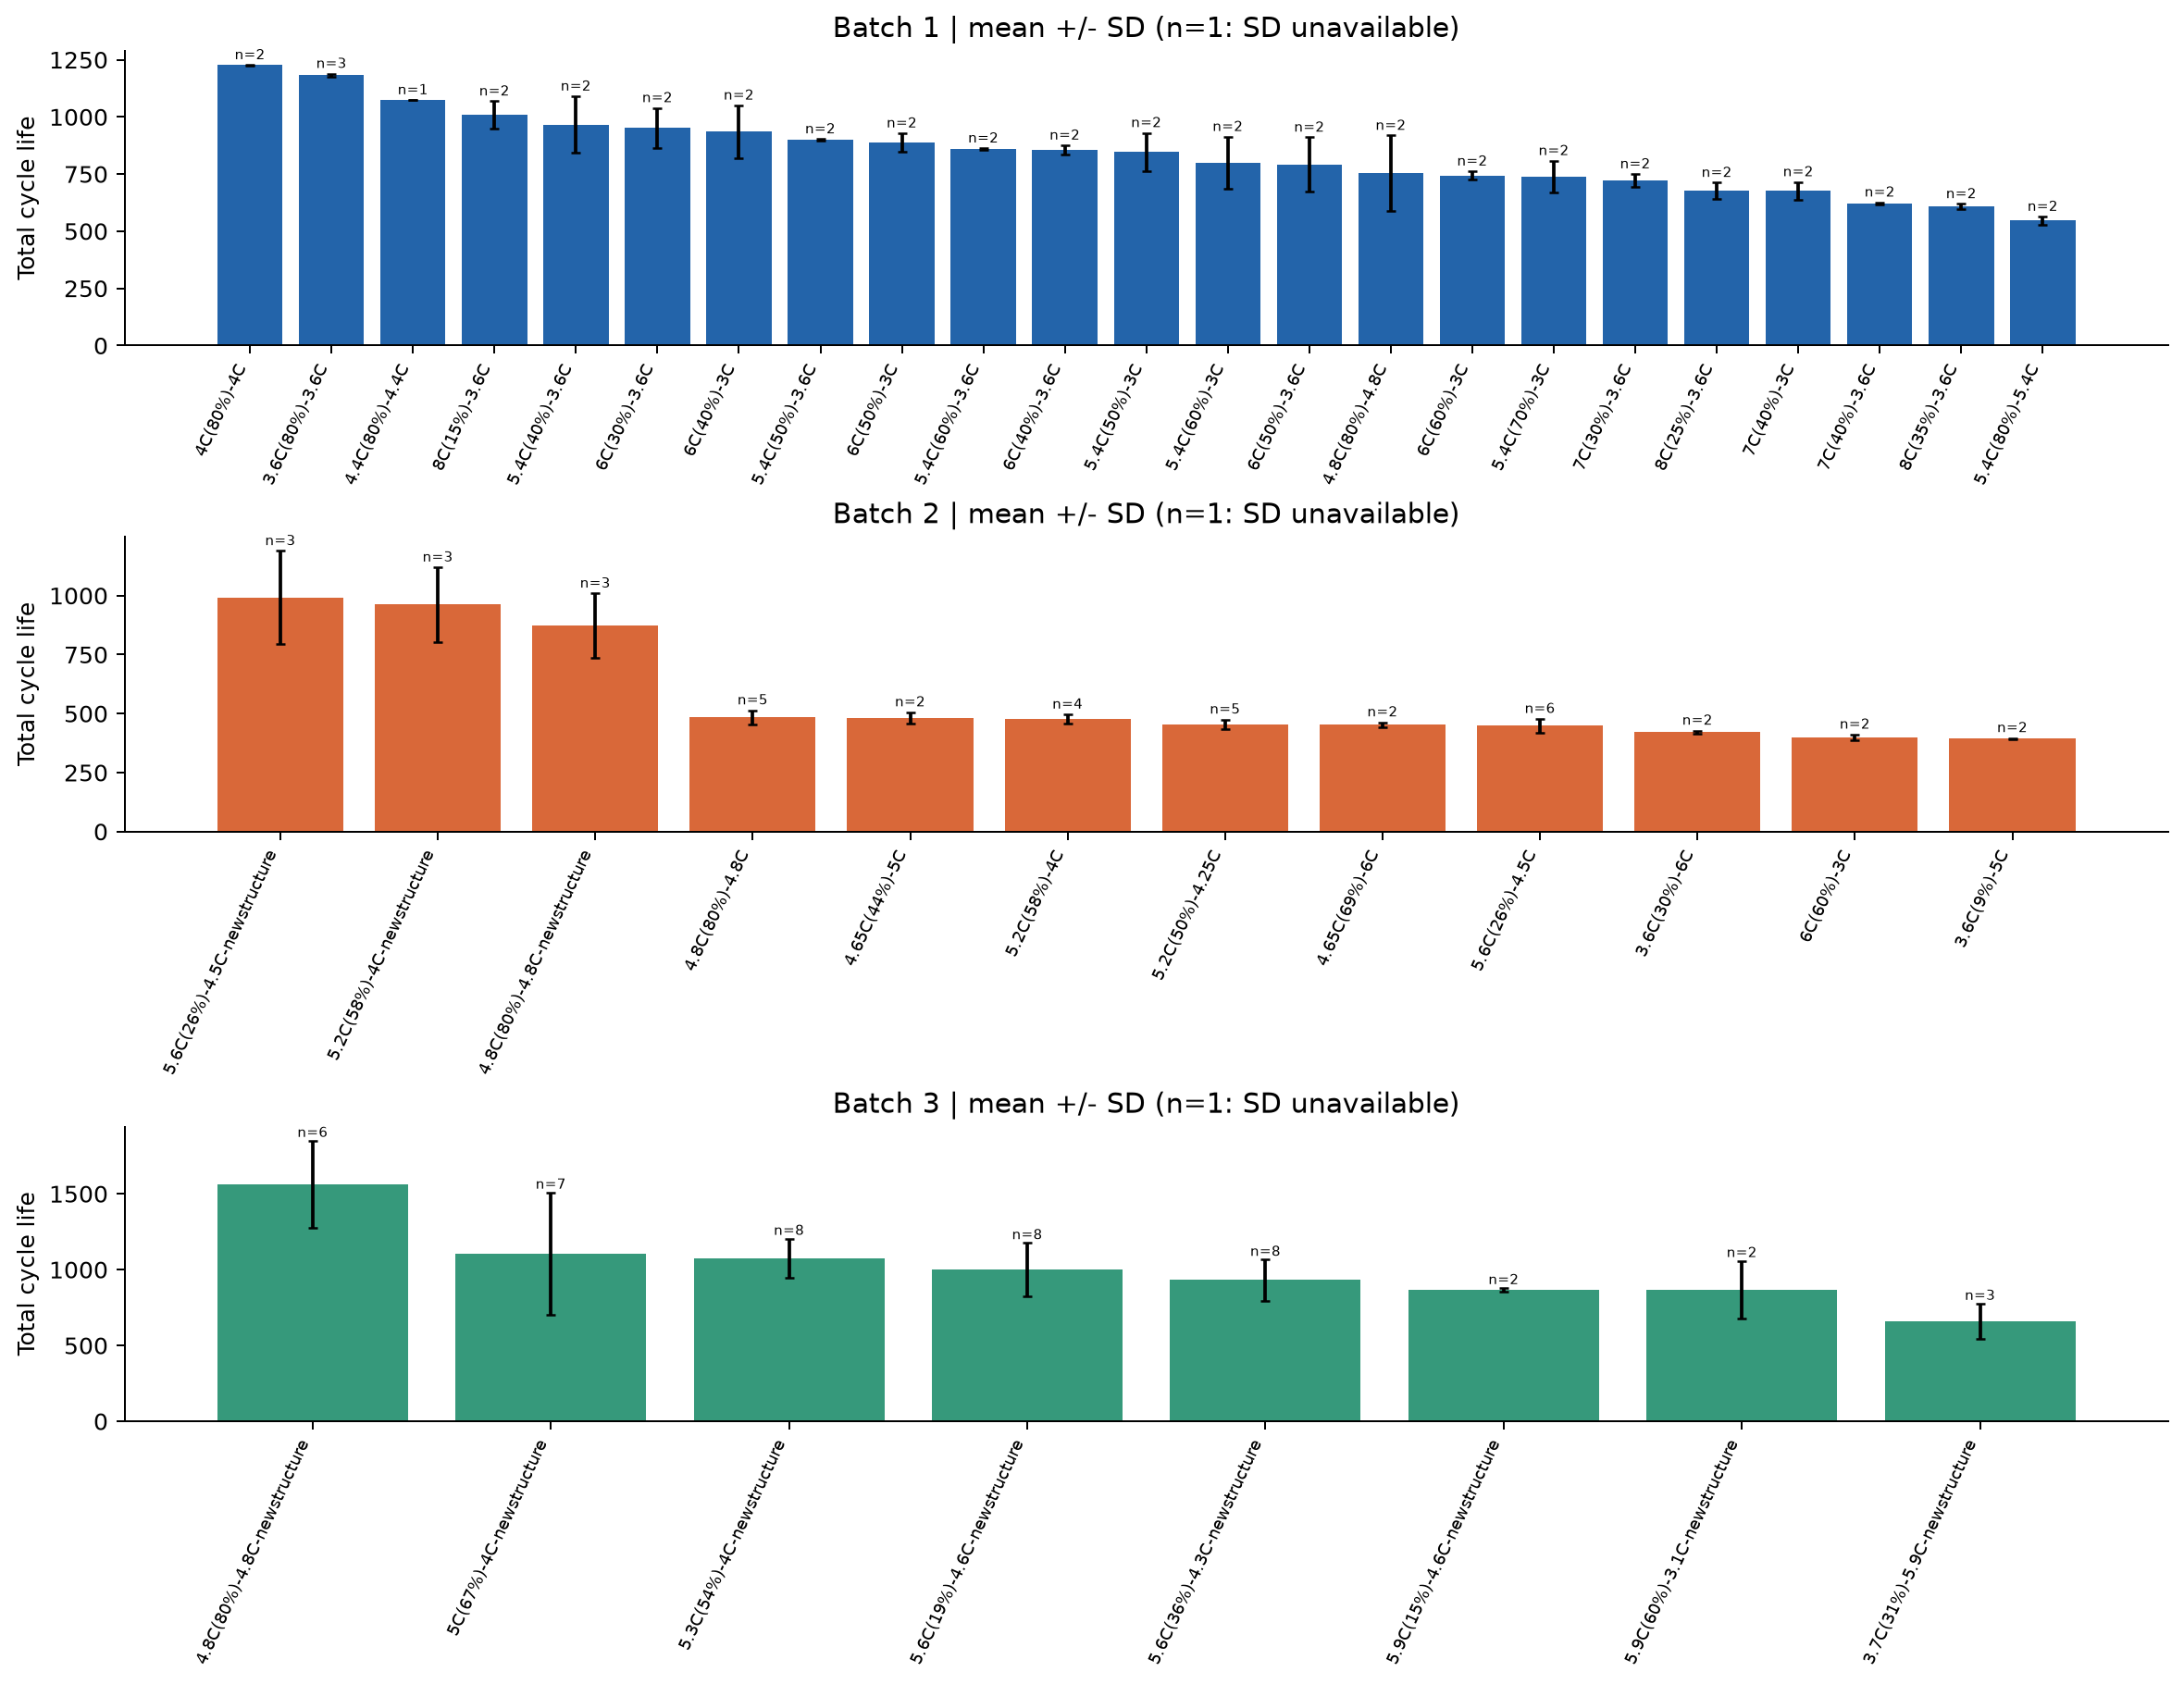

,batch,charging_policy,mean,std,count
0,Batch 1,3.6C(80%)-3.6C,1182.000000,7.000000,3
1,Batch 1,4.4C(80%)-4.4C,1074.000000,NaN,1
2,Batch 1,4.8C(80%)-4.8C,753.000000,165.462987,2
3,Batch 1,4C(80%)-4C,1226.500000,0.707107,2
4,Batch 1,5.4C(40%)-3.6C,966.500000,123.743687,2
5,Batch 1,5.4C(50%)-3.6C,899.500000,3.535534,2
6,Batch 1,5.4C(50%)-3C,847.000000,83.438600,2
7,Batch 1,5.4C(60%)-3.6C,859.500000,3.535534,2
8,Batch 1,5.4C(60%)-3C,799.500000,113.844192,2
9,Batch 1,5.4C(70%)-3C,739.500000,68.589358,2


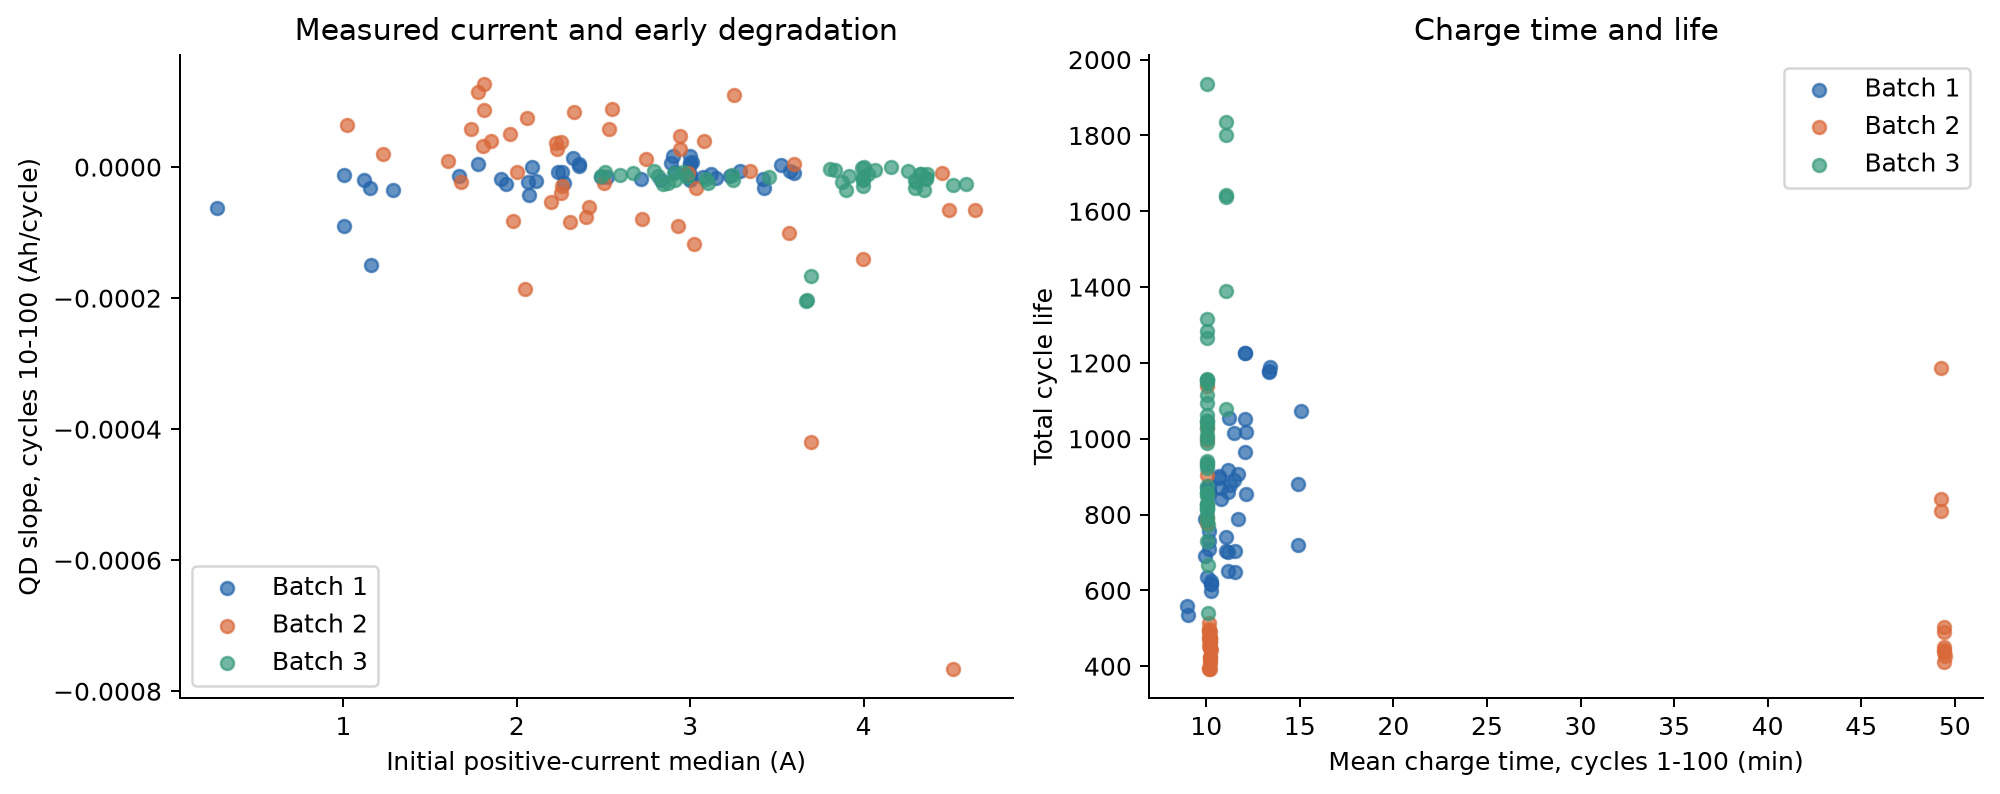

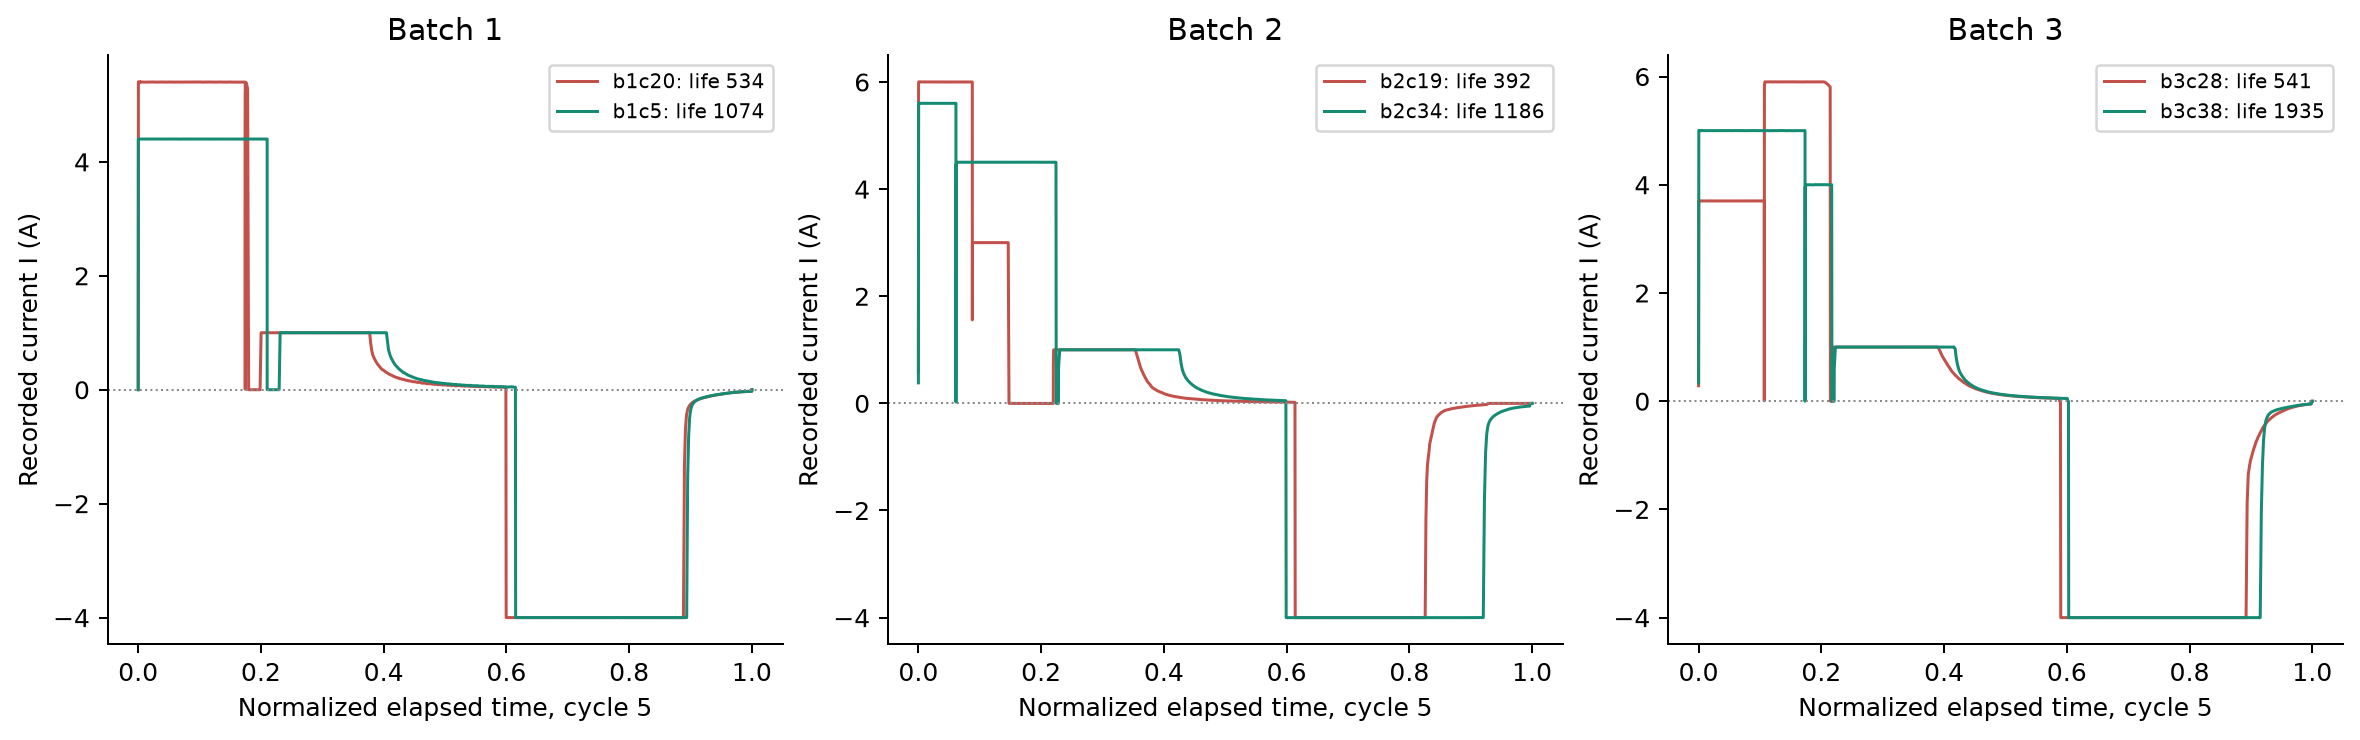

In [7]:
display(Image(filename=str(ROOT / "results/05_policy.png")))
display(pd.read_csv(ROOT / "results/policy_statistics.csv"))
display(Image(filename=str(ROOT / "results/10_charging_measurements.png")))
display(Image(filename=str(ROOT / "results/13_current_profiles.png")))

## Q4. 충전 프로토콜별 수명: 빠를수록 짧은가?

### 관찰

Batch 1에서 5.4C(80%)-5.4C는 평균 546.5(n=2), 8C(35%)-3.6C는 607.5(n=2)다. 더 빠른 첫 단계 정책이 항상 더 짧지 않다. Batch 3의 4.8C(80%)-4.8C는 평균 1564.2(n=6)로 긴 편이지만 다른 프로토콜·전환 SOC·배치 조건도 함께 다르다.

### 그룹 크기와 라벨 영향

막대는 평균, 에러바는 표준편차이며 신뢰구간이 아니다. n=1은 표준편차 추정 불가다. Batch 1의 상위 평균 정책에는 완료 불확실 셀이 있어 우열을 확정할 수 없다. Batch 2에서 유효 라벨이 없는 정책은 그래프에서 제외하고 정책표에는 남겼다.

### 시사점 → 피처·모델

정책을 c1·soc_switch·c2로 분해하고 실제 충전시간·전류를 함께 검토한다. 첫 단계 C-rate 하나로 수명을 설명하지 않는다. 정책별 타깃 평균을 그대로 입력하는 target encoding은 작은 그룹과 누수 위험이 커서 초기 모델에서 사용하지 않는다.

## Q4. 실제 전류 파형: 단계별 조건을 구분

| 배치 / 셀 | 수명 | 충전 프로토콜 | 5사이클 최대 I |
| --- | --- | --- | --- |
| Batch 1 / b1c20 | 534 | 5.4C(80%)-5.4C | 5.40 A |
| Batch 1 / b1c5 | 1074 | 4.4C(80%)-4.4C | 4.40 A |
| Batch 2 / b2c19 | 392 | 6C(60%)-3C | 6.00 A |
| Batch 2 / b2c34 | 1186 | 5.6C(26%)-4.5C-newstructure | 5.61 A |
| Batch 3 / b3c28 | 541 | 3.7C(31%)-5.9C-newstructure | 5.90 A |
| Batch 3 / b3c38 | 1935 | 5C(67%)-4C-newstructure | 5.00 A |

### 예시 선정과 축

완료 불확실 플래그가 없는 유효 라벨 셀 중 배치별 최소·최대 수명 셀을 선택했다. 이는 그룹 전체의 대표성을 보장하는 표본 추출이 아니라 실제 파형을 설명하는 6개 예시다. 실제 cycle 5의 I(t)를 읽고 시간은 각 사이클의 경과시간을 0~1로 정규화했다. 양수는 충전, 음수는 방전이다.

### 발견

Batch 3의 b3c28은 3.7C(31%)-5.9C 정책으로, 첫 단계가 낮아도 뒤 단계에서 기록 최대 I가 5.90 A다. 더 긴 b3c38은 5C(67%)-4C, 최대 5.00 A다. 단계별 세기와 전환점이 중요하며 c1 하나로 전체 충전 조건을 표현하기 어렵다.

### 시사점 → 패턴 피처

전체 양의 전류 중앙값은 오래 지속되는 낮은 전류 구간에 영향을 받아 빠른 단계의 세기를 놓칠 수 있다. 현재 요약값의 상관은 다음 페이지에서 비교한다. 추가 패턴 피처로 초기 충전 전류 상위 분위수·단계별 체류시간을 검토할 수 있으나, 아직 전체 셀에서 추출·검증한 최종 입력으로 주장하지 않는다.

## Q4. 실측 전류 패턴과 열화 속도의 관계

| 배치 | 실측 전류 vs 초기 QD 기울기 ρ | c1 vs 수명 ρ | 충전시간 vs 수명 ρ |
| --- | --- | --- | --- |
| Batch 1 | +0.408 | -0.483 | +0.613 |
| Batch 2 | -0.444 | +0.055 | -0.387 |
| Batch 3 | -0.103 | -0.229 | +0.196 |

### 어떤 전류를 비교했는가?

초기 1~5사이클에서 실측 I>0.1 A의 중앙값을 구하고 셀별 평균했다. 전체 전류 패턴의 요약값이며 단계별 체류시간·펄스·전환 구간을 모두 표현하지는 않는다. 정책 C-rate와 측정된 A 단위 전류는 구분했다. 전류 대 기울기의 n은 전체 46/47/46개, 수명 상관의 n은 유효 라벨 46/39/44개다.

### 관찰·배치 비교

전류와 초기 기울기의 상관은 +0.408/-0.444/-0.103으로 방향이 다르다. c1과 수명도 -0.483/+0.055/-0.229다. 충전시간은 +0.613/-0.387/+0.196으로 바뀐다. 이 자료만으로 고속 충전의 단일한 수명 효과를 확정할 수 없다.

### 시사점 → 검증

충전 조건 피처는 조건 의존적인 추가 후보로 다룬다. Batch 1에서 핵심 ΔQ 모델에 하나씩 추가해 개선 여부를 확인하고, 최종 평가에서 배치 차이를 해석한다. 개선되지 않으면 제외한다. c2·전환 SOC와의 상호작용은 제한된 복잡도로만 검토한다.


## 5. 초기 신호의 상관과 다중공선성

셀 단위 초기 100사이클 피처를 사용합니다. Spearman·Pearson과 유효 표본 수를 기록합니다. 0인 IR 값은 평균에 포함하지 않습니다.

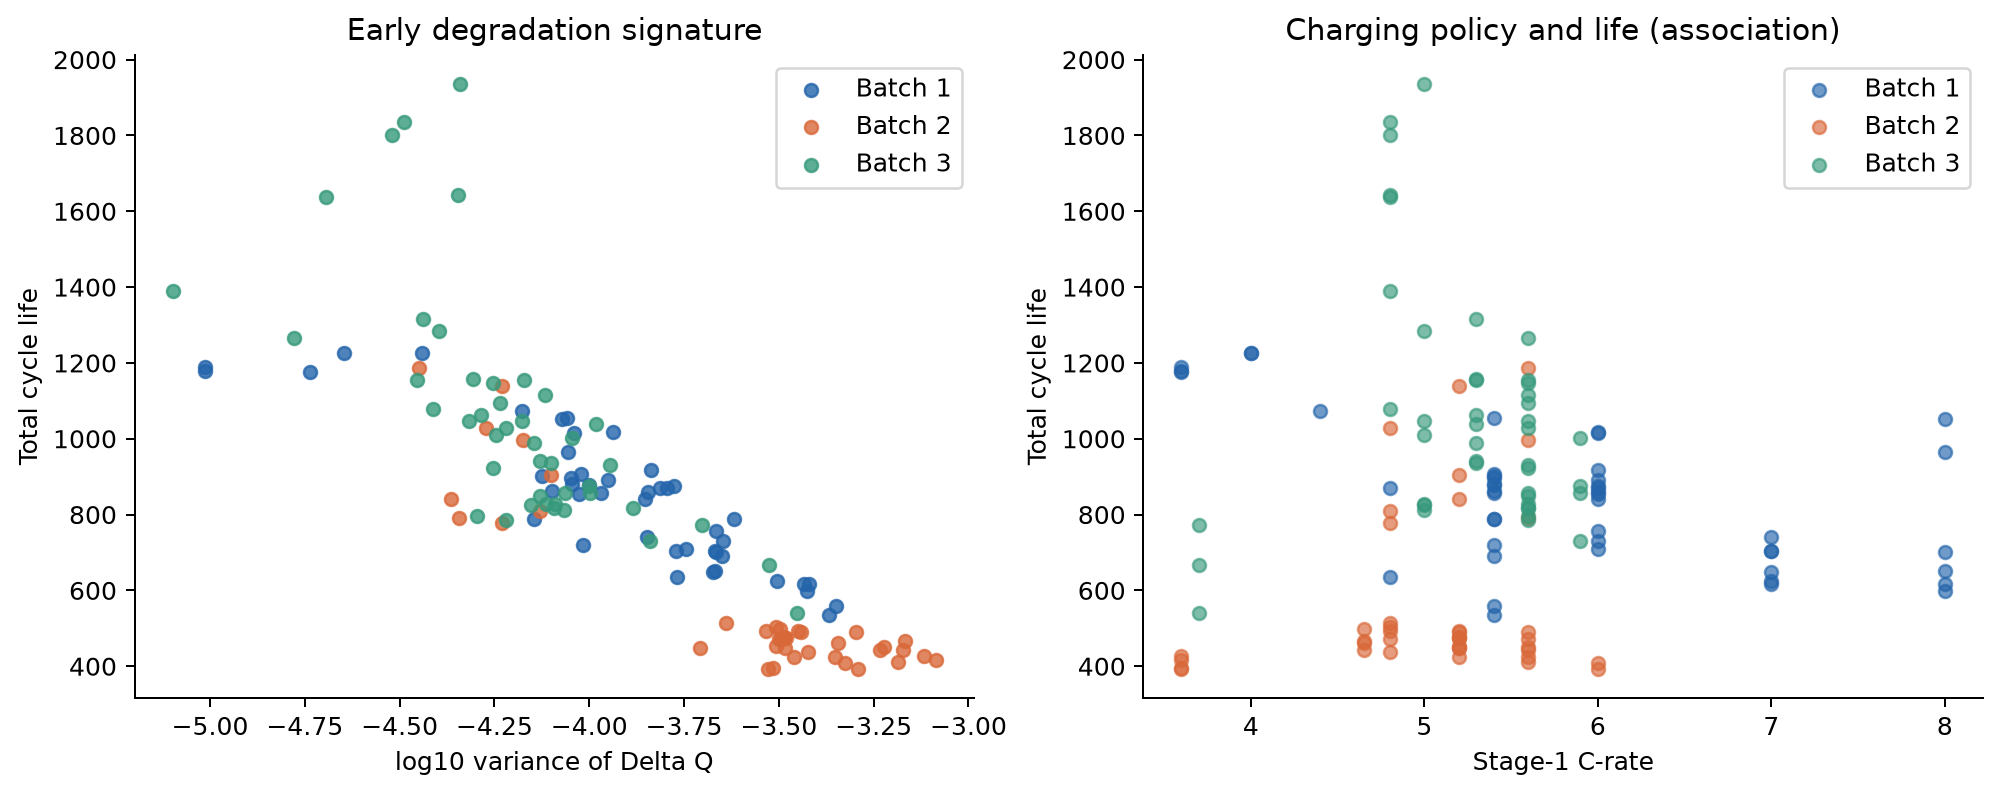

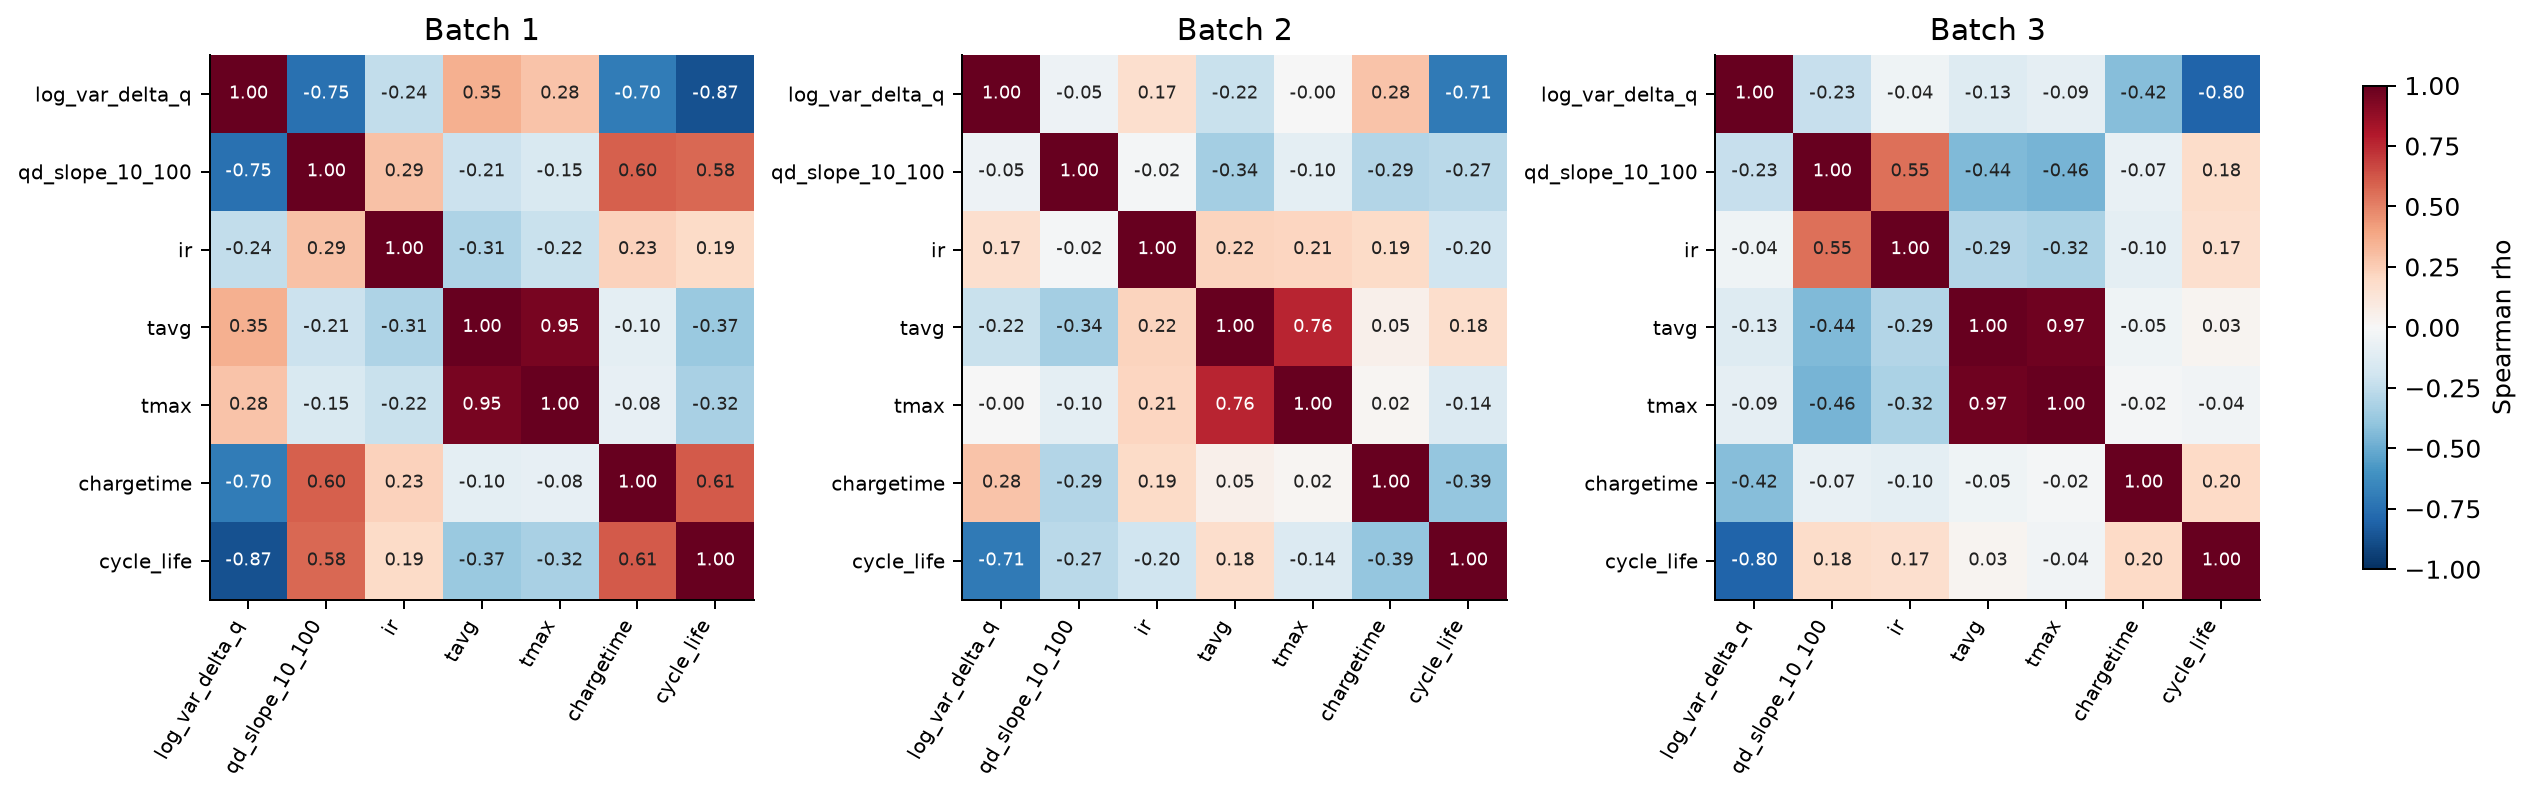

,batch,feature,n,spearman,p_unadjusted,pearson
0,Batch 1,log_var_delta_q,46,-0.871161,3.484999e-15,-0.886123
11,Batch 1,c1,46,-0.482714,6.798301e-04,-0.579719
8,Batch 1,mean_tavg,46,-0.371469,1.102952e-02,-0.481775
9,Batch 1,mean_tmax,46,-0.322992,2.856718e-02,-0.403596
7,Batch 1,delta_ir,46,-0.232577,1.198469e-01,0.130575
5,Batch 1,std_qd,46,0.030653,8.397435e-01,-0.242984
13,Batch 1,c2,46,0.047414,7.543523e-01,-0.095887
12,Batch 1,soc_switch,46,0.185159,2.179729e-01,0.234551
6,Batch 1,mean_ir,46,0.189034,2.083237e-01,0.217968
4,Batch 1,mean_qd,46,0.225978,1.310218e-01,0.204505


log_var_delta_q          -0.826232
min_delta_q               0.786716
mean_delta_q              0.758013
qd_slope_10_100           0.504569
mean_chargetime           0.477410
early_positive_current    0.263612
mean_qd                   0.259879
c1                       -0.237410
delta_ir                 -0.232205
mean_ir                   0.195521
std_qd                   -0.183421
c2                       -0.161241
mean_tavg                -0.116360
mean_tmax                -0.102458
soc_switch               -0.058890
Name: spearman_terminal_screened, dtype: float64

In [8]:
display(Image(filename=str(ROOT / "results/04_early_signals.png")))
display(Image(filename=str(ROOT / "results/06_correlations.png")))
display(corr.sort_values(["batch","spearman"]))
# Batch 1 수명 미완료 가능 셀 제외에 따른 민감도
eligible = cells[(cells.batch == "Batch 1") & ~cells.eol_not_observed]
sensitivity = eligible[eda.FEATURES + ["cycle_life"]].corr(method="spearman")["cycle_life"].drop("cycle_life").rename("spearman_terminal_screened")
sensitivity.to_csv(ROOT / "results/batch1_eol_sensitivity.csv")
display(sensitivity.sort_values(key=abs,ascending=False))

## Q5. 어떤 초기 신호가 수명과 연결되는가?

| 초기 피처 | Batch 1 ρ (n) | Batch 2 ρ (n) | Batch 3 ρ (n) |
| --- | --- | --- | --- |
| log_var_delta_q | -0.871 (46) | -0.709 (39) | -0.797 (44) |
| min_delta_q | +0.850 (46) | +0.661 (39) | +0.776 (44) |
| mean_delta_q | +0.828 (46) | +0.697 (39) | +0.756 (44) |
| mean_chargetime | +0.613 (46) | -0.387 (39) | +0.196 (44) |
| qd_slope_10_100 | +0.578 (46) | -0.271 (39) | +0.184 (44) |
| c1 | -0.483 (46) | +0.055 (39) | -0.229 (44) |
| mean_tavg | -0.371 (46) | +0.176 (39) | +0.025 (44) |
| mean_ir | +0.189 (46) | -0.199 (33) | +0.169 (44) |

### 가장 강한 관계

각 배치에서 제시한 초기 후보 중 ΔQ log 분산의 절대 상관이 가장 크다. 최솟값·평균도 방향이 일관된다. 초기 평균 용량은 +0.226/+0.112/+0.162로 상대적으로 약해, 초기 수준 자체보다 변화량이 더 유용한 후보라는 근거가 된다.

### 배치 간 안정성

온도와 충전시간·기울기의 관계는 약해지거나 부호가 바뀐다. Batch 1의 상관 순위만으로 범용 피처라고 주장하지 않는다. 외부 배치의 관찰은 조건 의존성을 설명하는 데 사용하며 모델 선택·튜닝은 Batch 1 안에서 한다.

### 통계 해석

Spearman은 단조 관계, Pearson은 선형 관계를 확인한다. 상관은 탐색적 근거로, 예측 성능·인과·독립적인 효과를 입증하지 않는다. 결측을 쌍별로 제외하고 n을 기록했다. 여러 피처의 p-value는 다중 비교 보정 없는 탐색 결과다.

## Q5. 다중공선성: 강한 신호를 중복 넣지 않기

| 변수 쌍 | Batch 1 | Batch 2 | Batch 3 |
| --- | --- | --- | --- |
| log_var_delta_q / min_delta_q | -0.987 | -0.982 | -0.982 |
| log_var_delta_q / mean_delta_q | -0.971 | -0.967 | -0.972 |
| min_delta_q / mean_delta_q | +0.989 | +0.950 | +0.985 |
| mean_tavg / mean_tmax | +0.951 | +0.759 | +0.975 |
| c1 / soc_switch | -0.869 | -0.239 | -0.649 |

### 관찰

ΔQ 요약량 세 개는 상호 |ρ|가 약 0.95~0.99로 거의 같은 정보를 담는다. Tavg/Tmax는 0.951/0.759/0.975로 중복되고 Batch 1의 c1/전환 SOC도 -0.869로 연결된다. 이 값은 단조 중복의 근거이며 선형 공선성을 정량화하는 VIF와 동일하지 않다.

### 모델 영향 → 대응

일반 선형 회귀에서 중복 피처는 계수를 불안정하게 만들 수 있다. 초기 모델은 ΔQ log 분산 하나와 평균 온도 하나를 사용하고, Ridge/ElasticNet으로 축소 또는 선택을 검토한다. 트리는 계수 문제는 다르지만 중복 피처의 중요도가 분산될 수 있어 해석을 주의한다.

### 검증 기준

피처 제거·선택과 스케일링은 CV 학습 fold에서만 수행한다. 필요하면 그 fold에서 Pearson 공선성·VIF도 확인한다. 중복량을 늘린 모델이 검증 평균뿐 아니라 fold 간 변동도 개선하는지 비교한다.


## Feature Engineering: 가설에서 선택 기준까지

| 피처 묶음 | 사용할 입력 | 선정 이유 / 확인할 사항 |
| --- | --- | --- |
| G0 핵심 기본형 | log_var_delta_q | 세 배치 일관된 방향, 완료 불확실 제외에도 관계 유지. 먼저 이 신호만으로 기준을 만든다. |
| G1 초기 추세 | G0 + qd_slope_10_100 | 열화 곡선의 국소 추세. 배치별 부호 차이 때문에 추가 효과를 검증한다. |
| G2 충전 조건 | G1 + mean_chargetime + c1 | 정책·실측 조건 보완. 충전 조건이 바뀌는 환경에서도 일반화 가능한지는 미확정. |
| G3 열적 조건 | G2 + mean_tavg | 온도 영향 후보. Tmax는 중복이 커서 동시에 쓰지 않는다. |
| 대체 / 확장 후보 | min_delta_q, mean_delta_q, IR 변화, c2, 전환 SOC, 실측 전류 | 핵심 ΔQ 요약량 교체 또는 정규화 비교. 추가 변수가 필요하다는 근거는 CV로 확인. |
| 입력 제외 | cycle_life, label550, last_cycle, 전체 knee, 종료 QD, observed_eol_cycle, 배치 ID·셀 ID | 타깃 또는 예측 시점 이후 정보, 식별자. 완료 플래그는 라벨 검토용이며 X가 아니다. |

### 선별 절차

G0→G1→G2→G3를 동일한 Batch 1 분할로 비교한다. 후보 집합은 좁게 유지하고 추가로 얻는 CV MAPE 개선과 fold 간 안정성을 확인한다. 개선이 작거나 불안정하면 더 단순한 집합을 선택한다. 실제 최종 집합은 DAY 2 검증 후 확정한다.

### 예측 시점과 결측

summary 평균은 cycle≤100, 기울기는 10~100, IR 변화는 1~10 대비 91~100, 실측 전류는 1~5를 사용한다. 결측 대체는 학습 fold 중앙값으로 한다. 결측 표시 피처를 추가할 경우에도 초기 관측에서 계산한 표시만 허용한다.

### 참고 이미지와의 연결

입력 변수의 출처와 가설, 타깃과 입력의 구분, 시계열에서 미래값을 사용하지 않는 기준을 명시했다. 원논문 피처를 무조건 복제하지 않고 이번 데이터의 배치 차이와 라벨 품질을 반영했다.

## Regression 선택과 Target 변환 검토

| 항목 | 회귀: 이번 선택 | 분류: 선택하지 않은 이유 |
| --- | --- | --- |
| 예측 시점 / 타깃 | 100사이클 / cycle_life 수치 | 5사이클 / life≥550이면 1 |
| 정보 활용 | ΔQ100−10과 100사이클 요약 사용 가능 | ΔQ100−10을 사용하면 시점 위반 |
| Batch 1 분포 | 연속 수명 534~1227 활용 | 클래스 0/1 = 1/45로 검증 매우 불안정 |
| 업무 해석 | 셀별 예상 사이클 수·선별 우선순위 | 550 기준 통과 여부로 정보가 압축됨 |

### 변환 전후 확인

원 수명→자연로그 수명의 왜도는 Batch 1 0.45→0.04, Batch 2 1.64→1.36, Batch 3 1.26→0.52다. 로그 후 일부 비대칭은 줄지만 모든 배치가 정규분포가 되는 것은 아니다.

### 시사점 → 타깃 처리

Batch 1에서 원 타깃과 log 타깃을 제한된 후보로 비교한다. log 모델은 예측 후 exp로 사이클 단위로 복원하고 원 단위 MAPE·MAE·RMSE로 평가한다. MAPE 최적과 log 제곱오차 최적은 같지 않으므로 변환을 자동 확정하지 않는다. 매출 예시의 Tweedie 분포를 배터리 수명에 그대로 적용하지 않는다.

## Modeling Strategy: 데이터 특성에 맞는 후보 모델

| 후보 | EDA 근거와 알고리즘 관점 | 복잡도·선택 조건 |
| --- | --- | --- |
| 중앙값 기준 모델 | 작은 표본에서도 해석 가능한 비교 기준. 배치별 수명 범위 차이의 영향을 확인. | 모든 학습 fold의 라벨 중앙값만 사용. 학습 데이터 밖 타깃을 참조하지 않는다. |
| Ridge / ElasticNet | ΔQ 요약량·온도 중복과 46개 이하의 작은 학습 표본. 계수를 정규화해 분산을 줄인다. | 중앙값 대체→표준화→정규화 회귀. alpha는 작은 로그 간격 후보, ElasticNet 혼합비도 좁게 비교. |
| Random Forest | 충전 조건·온도와 곡선 변화의 비선형 상호작용 가능성. 분할 평균으로 비선형을 표현한다. | 깊이·최소 리프 표본을 제한. 타깃 학습 범위 밖으로 직접 외삽하기 어려워 장수명 구간 오차를 확인. |
| 얕은 Gradient Boosting | 단순 모델에 남는 비선형 잔차를 작은 트리로 순차 보완한다. | 깊이 1~2, 적은 트리·낮은 학습률을 제한적으로 비교. 작은 표본에서 튜닝 폭을 넓히지 않는다. |

### 왜 딥러닝·1000차원 곡선 모델을 우선 쓰지 않는가?

학습 독립 표본은 Batch 1 최대 46개이며 라벨 검토 후 더 줄 수 있다. 116,722개 사이클 행이 독립 셀 표본 수를 늘려주지는 않는다. 많은 파라미터나 곡선 포인트로 시작하면 표본 대비 복잡도가 커지고 검증이 불안정해진다.

### LightGBM을 반드시 써야 하는가?

참고 이미지의 LightGBM은 매출 데이터의 구체적 선택 예시다. 본 프로젝트에서는 부스팅 계열을 후보로 두되 현재 표본 수에서 정규화 회귀보다 유리하다는 근거가 없다. 추가 라이브러리나 최신 알고리즘 자체를 선정 이유로 삼지 않는다.

### 최종 선택 원칙

CV 평균 MAPE가 낮고 fold 간 변동이 작은 후보를 우선한다. 성능 차이가 미미하면 피처 수와 복잡도가 작은 모델을 선택한다. 정규화 회귀도 외삽이 항상 정확한 것은 아니므로 Batch 2·3 평가에서 실제 한계를 보고한다.

## 데이터 처리·검증·오류 분석의 구체적 계획

### 학습 라벨 품질의 기본안

Batch 1 완료 불확실 10개를 제외한 36개를 주 분석 대상으로 검토하고, 46개 전체를 사용한 민감도 비교를 별도로 보고한다. 제외는 명시한 종료 용량 기준에 따르며 결과를 보고 유리한 셀만 삭제하지 않는다. 어느 라벨 정책을 주 결과로 삼을지는 분할 전에 고정한다.

### 분할

셀 단위 Hold-out 약 20%를 random_state=42로 먼저 고정한다. 충전 프로토콜 그룹 분리를 우선 검토하고 그룹 수·학습 표본 수가 허용하면 학습 부분에서 GroupKFold 약 5분할을 사용한다. 그룹 분리가 불가능하면 셀 단위 분할의 한계를 공개한다. Hold-out은 피처·튜닝 선택에 사용하지 않는다.

### Pipeline

각 CV 학습 fold에서 결측 중앙값 대체→선형 모델용 StandardScaler→모델 fit을 수행한다. 트리 모델은 불필요한 스케일링을 생략한다. 초기 측정치 기반 결측 지표는 선택 후보이며 전체 기록의 invalid 카운트는 입력에서 제외한다. 선택한 피처·파라미터·타깃 변환은 Hold-out 및 외부 평가 전에 고정한다.

### 외부 평가와 지표

Batch 2의 유효 라벨 39개로 최종 평가하되 명시한 품질 정책을 일관되게 적용하고 평가 n을 보고한다. Batch 3도 같은 정책으로 추가 평가한다. 주 지표 MAPE=100×mean(|y−ŷ|/y), 보조 MAE·RMSE를 사이클 단위로 보고한다. 타깃이 모두 양수여서 0 나눗셈은 없지만 작은 수명에 상대 오차가 더 민감하다.

### 오차를 어떻게 해석하는가?

CV 평균과 표준편차, Hold-out, Batch 2·3를 분리한다. Gap은 Valid−CV, Test−Valid, Test−9.1%(%p)로 정의한다. 큰 오차 셀의 수명 구간·충전 정책·초기 곡선·결측 패턴을 확인하고 편향을 설명한다. 이때 외부 타깃으로 다시 튜닝하지 않는다.

### 외부 EDA의 한계

DAY 1 요구에 따라 세 배치의 라벨을 이미 관찰했다. 외부 데이터를 완전히 눈가림했다고 주장하지 않는다. 배치별 관찰은 해석과 검증 위험 설명에 사용하고, 실질적인 모델·피처 선택은 Batch 1 학습 부분 안에서 수행한다.

## EDA Insight → Feature → Modeling Strategy

| 관찰한 사실 | 피처·처리 결정 | 후보 모델·검증으로 연결 |
| --- | --- | --- |
| ΔQ log 분산<br>ρ=-0.871 / -0.709 / -0.797 | 핵심 G0 피처로 선정. 완료 불확실 제외 민감도 확인. | 단일 피처 Ridge부터 시작하고 기준 모델 대비 개선 확인. |
| ΔQ 요약량 /ρ/≈0.95~0.99, 온도 중복 큼 | 요약량 하나·온도 하나 우선. 확장 시 정규화. | Ridge/ElasticNet 계수·fold 변동 확인. |
| 충전시간·초기 기울기의 수명 상관 방향 변함 | G1~G3로 하나씩 추가. 조건 의존 후보로 취급. | Batch 1 ablation 비교와 외부 배치 잔차 해석. |
| 학습 셀 최대 46개, 라벨 품질 검토 시 36개 | 1000차원 곡선 대신 작은 요약 피처. | 얕은 트리·좁은 튜닝. 딥러닝 우선 제외. |
| Batch 2 단수명 71.8%, Batch 3 장수명 52.3% | 배치 ID를 모델 입력으로 넣지 않음. 타깃 구간별 평가. | 학습 범위 밖 타깃과 입력 지원 범위를 분리해 점검. |
| 초기 용량 일부 증가, knee는 전체 궤적에 의존 | 전체 knee·종료값 제외. 초기 국소 추세만 후보. | 100사이클 시점 준수·누수 차단. |
| 완료 불확실 16개, 라벨 결측 10개 | 별도 품질 플래그·사전 포함 기준. | 라벨 검토·평가 n·민감도 분석 공개. |

### 업무 관점의 활용

예상 총수명은 셀 선별이나 교체 우선순위의 참고 근거가 된다. 셀 간 비교와 초기 열화 신호 탐색이 목적이며, 현재 분석으로 실제 ESS 교체 날짜나 안전 제어를 직접 결정할 수는 없다. 운전 조건 변화·캘린더 열화·시간 단위 수명 변환·불확실성을 검증해야 한다.


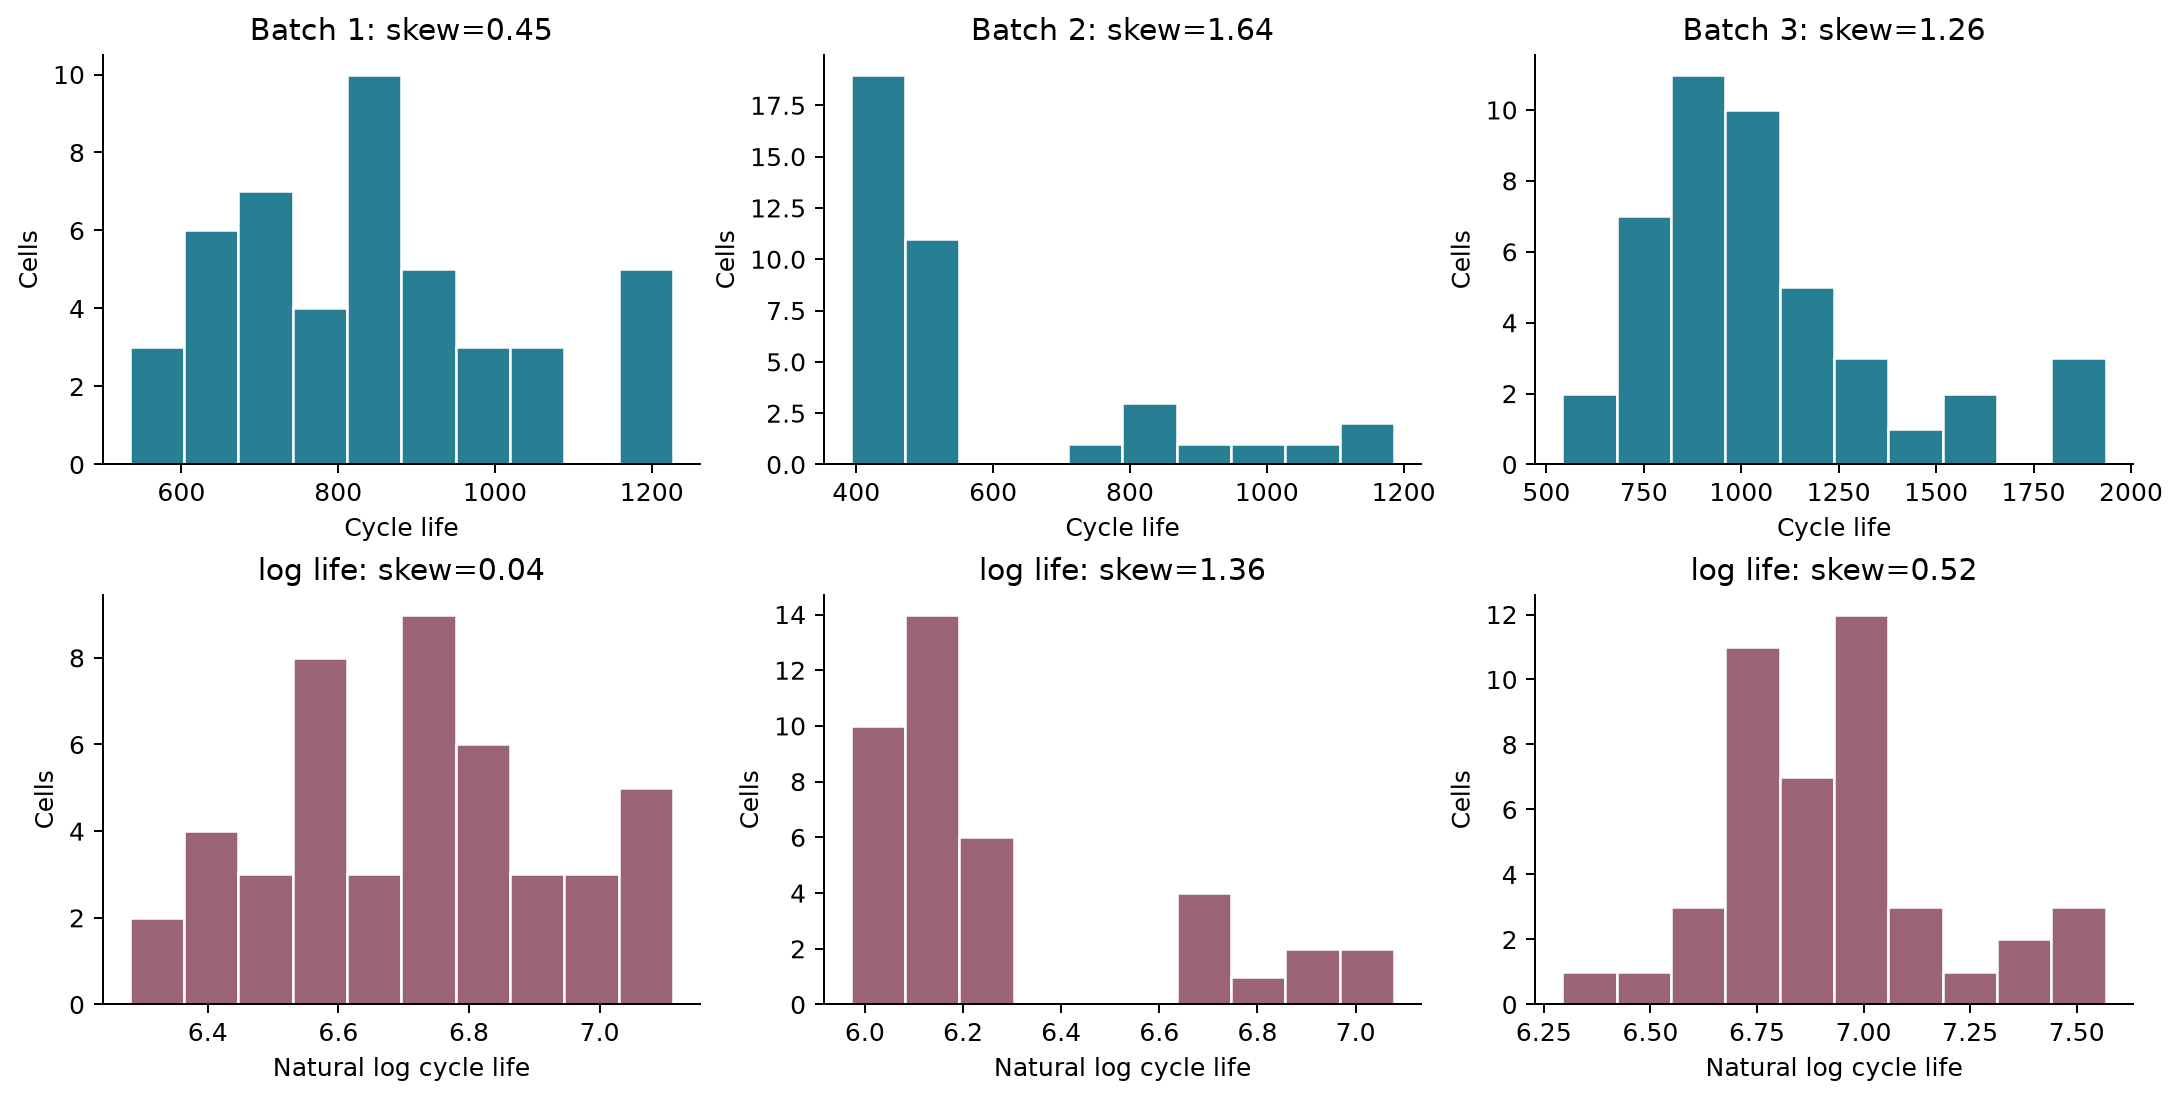

In [9]:
display(Image(filename=str(ROOT / "results/12_target_transformation.png")))

## 7. 재현 환경과 제출

DAY1 17시 PDF, DAY2 16시 public GitHub 링크. 팀원과 파일명은 제출 전에 확인하세요.

실습 가이드: https://actually-war-1ea.notion.site/DS-Mini-Project-32d7f4c8669380338a27f90c471c1fcb

데이터: https://www.kaggle.com/datasets/itshpark/data-driven-prediction-of-battery-cycle

연구진 로더: https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation

In [10]:
import importlib.metadata as metadata
packages = ["numpy","pandas","matplotlib","scipy","h5py","scikit-learn","nbformat","nbclient"]
display(pd.DataFrame({"package":packages,"version":[metadata.version(x) for x in packages]}))

,package,version
0,numpy,2.3.5
1,pandas,2.2.3
2,matplotlib,3.11.2
3,scipy,1.18.1
4,h5py,3.16.0
5,scikit-learn,1.9.1
6,nbformat,5.11.1
7,nbclient,0.11.0
